# First-Passage Dynamics of Drawdown Cascades in Equity Markets

**Paper pipeline** — Kramers–Moyal analysis of drawdown processes  
Analog to pacing-collapse dynamics (PRE framework)

**Markets**: S&P 500 (`^GSPC`), COLCAP (`^COLCAP`)  
**Method**: Drawdown process → Langevin/Fokker–Planck → KM coefficients → First-passage distributions

---
```
Sections:
  0. Setup & imports
  1. Data acquisition (yfinance)
  2. Drawdown process construction
  3. Kramers–Moyal estimation
  4. Fokker–Planck / Langevin validation
  5. First-passage time distributions
  6. Tail exponent estimation
  7. Cross-market universality (scaling collapse)
  8. GARCH(1,1) benchmark
  9. Paper figures (publication quality)
```

## 0. Setup & Imports

In [1]:
# Install / upgrade dependencies (run once)
!pip install yfinance arch ruptures statsmodels --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats, optimize, signal
from scipy.interpolate import UnivariateSpline
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf

# --- Plotting style (publication-ready) ---
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False,   # set True if LaTeX installed
})

# Color palette (consistent across all figures)
COLORS = {
    'sp500':  '#1f4e8c',   # dark blue
    'colcap': '#c0392b',   # dark red
    'theory': '#2ecc71',   # green
    'garch':  '#95a5a6',   # gray
    'accent': '#e67e22',   # orange
}

FIGDIR = 'figures/'
import os
os.makedirs(FIGDIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Data Acquisition

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^SPCOSLCP']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-01-01 -> 2024-12-31)')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^COLCAP']: YFTzMissingError('possibly delisted; no timezone found')


sp500    | ^GSPC        |  8816 días | 1990-01-02 → 2024-12-30
colcap   | CIB          |  3773 días | 2010-01-04 → 2024-12-30

Mercados activos : ['sp500', 'colcap']
Tickers usados   : {'sp500': '^GSPC', 'colcap': 'CIB'}

--- Estadísticos de retornos ---

S&P 500 (^GSPC)
  Retorno medio    : 8.00% anualizado
  Volatilidad      : 18.06% anualizada
  Skewness         : -0.399
  Kurtosis (excess): 10.676

S&P Colombia Select (CIB)
  Retorno medio    : 2.28% anualizado
  Volatilidad      : 32.62% anualizada
  Skewness         : -0.378
  Kurtosis (excess): 17.665


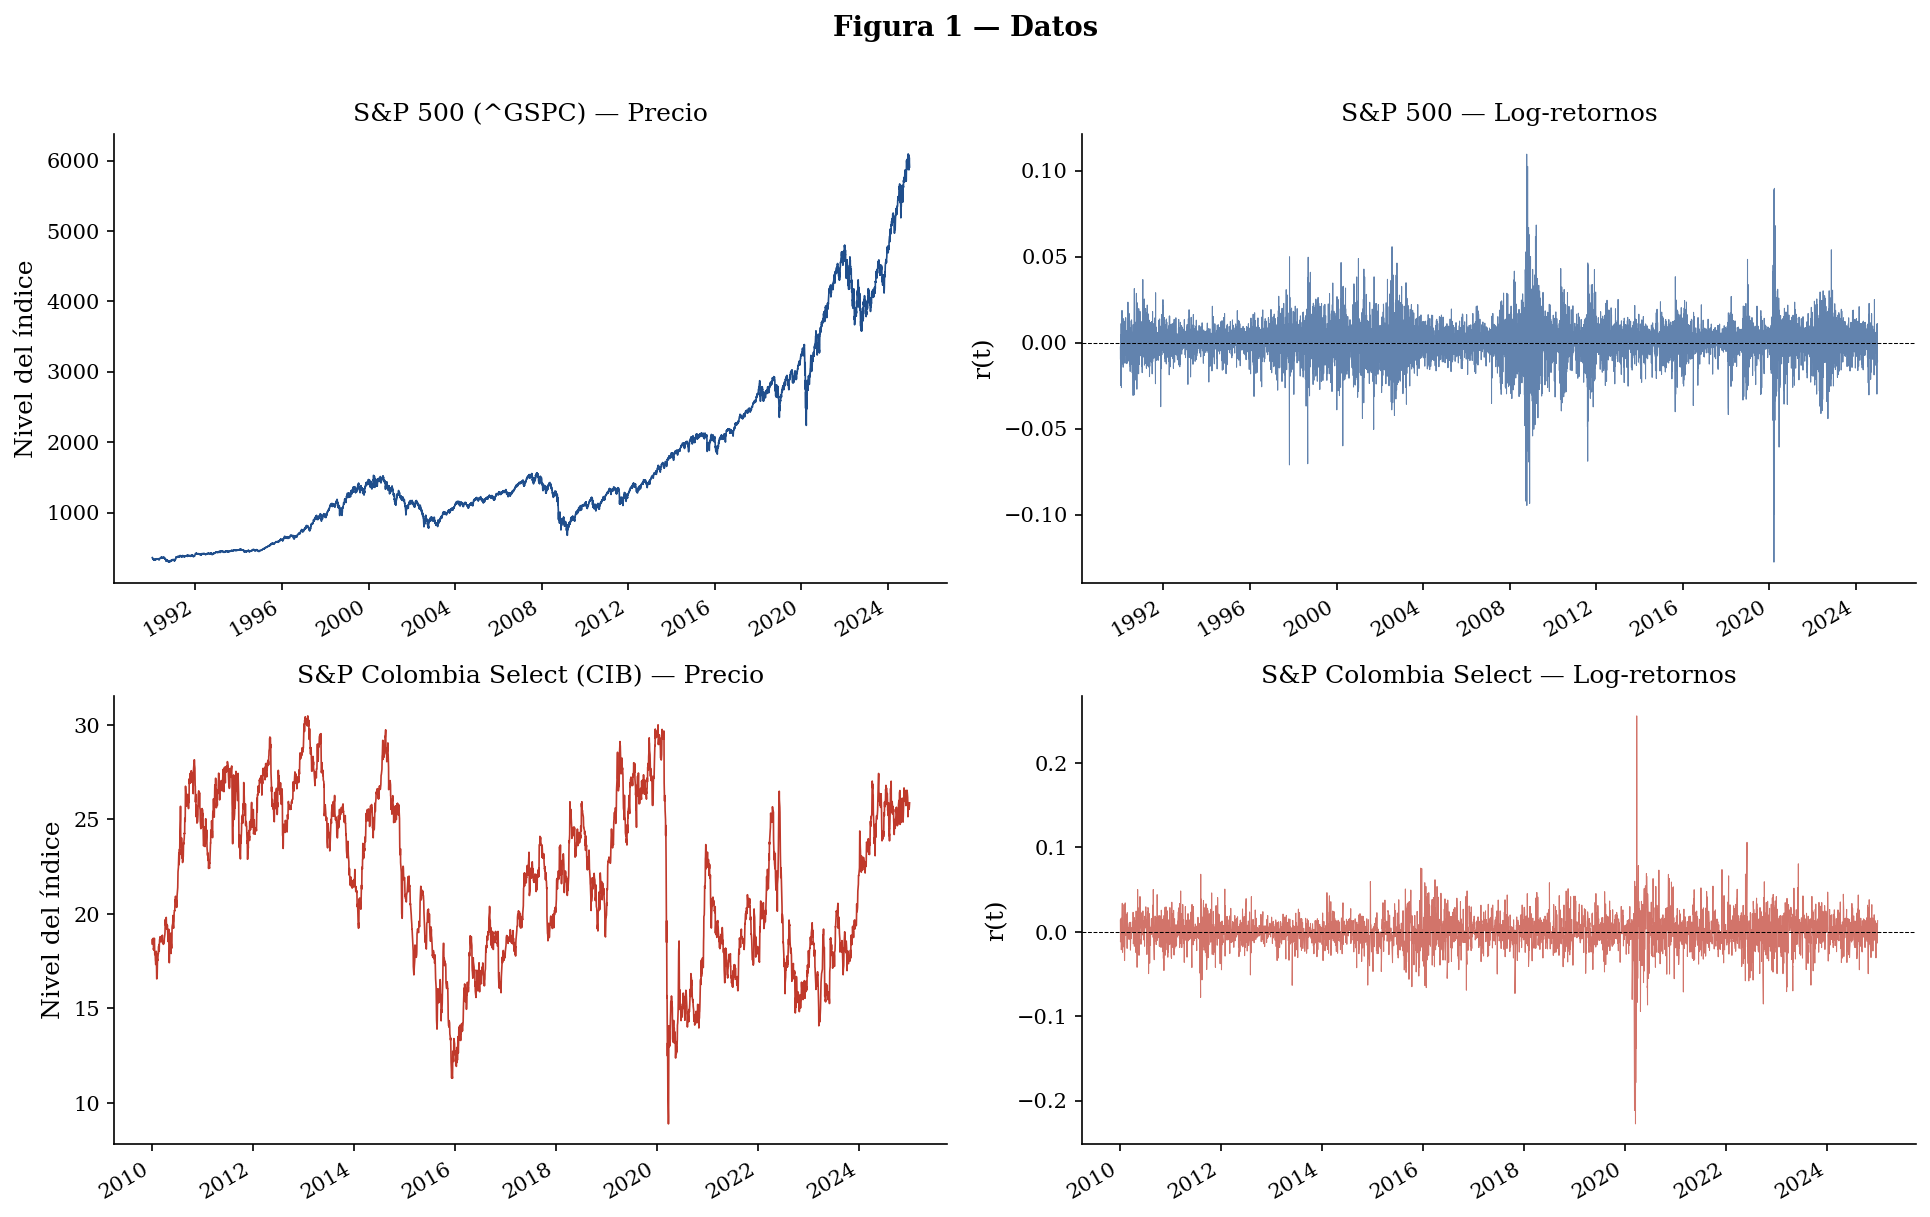

In [6]:
# --- Tickers ---
COLCAP_CANDIDATES = ['^SPCOSLCP', '^COLCAP', 'CIB', 'GXG']

PERIODS = {
    'sp500':  ('1990-01-01', '2024-12-31'),
    'colcap': ('2010-01-01', '2024-12-31'),
}

LABELS = {
    'sp500':  'S&P 500',
    'colcap': 'S&P Colombia Select',
}

def try_download(ticker, start, end):
    try:
        df = yf.download(ticker, start=start, end=end,
                         auto_adjust=True, progress=False)
        close = df['Close'].dropna().squeeze()
        if isinstance(close, pd.Series) and len(close) > 100:
            return close, ticker
    except Exception:
        pass
    return None, None

raw = {}
ticker_used = {}

# S&P 500
raw['sp500'], ticker_used['sp500'] = try_download('^GSPC', *PERIODS['sp500'])

# Colombia — prueba candidatos en orden
raw['colcap'], ticker_used['colcap'] = None, None
for ticker in COLCAP_CANDIDATES:
    result, t = try_download(ticker, *PERIODS['colcap'])
    if result is not None:
        raw['colcap'] = result
        ticker_used['colcap'] = t
        break

# Mercados activos
MARKETS = [name for name, s in raw.items() if s is not None]

# --- Log-retornos ---
returns = {}
for name in MARKETS:
    r = np.log(raw[name] / raw[name].shift(1)).dropna().squeeze()
    returns[name] = r

# --- Reporte ---
for name in MARKETS:
    s = raw[name]
    print(f"{name:8s} | {ticker_used[name]:12s} | {len(s):5d} días | "
          f"{s.index[0].date()} → {s.index[-1].date()}")

print(f"\nMercados activos : {MARKETS}")
print(f"Tickers usados   : { {k: v for k, v in ticker_used.items() if v} }")

# --- Estadísticos básicos ---
print('\n--- Estadísticos de retornos ---')
for name in MARKETS:
    r = returns[name]
    mean_ann  = float(r.mean()) * 252
    vol_ann   = float(r.std()) * np.sqrt(252)
    skew      = float(r.skew())
    kurt      = float(r.kurtosis())
    print(f"\n{LABELS[name]} ({ticker_used[name]})")
    print(f"  Retorno medio    : {mean_ann:.2%} anualizado")
    print(f"  Volatilidad      : {vol_ann:.2%} anualizada")
    print(f"  Skewness         : {skew:.3f}")
    print(f"  Kurtosis (excess): {kurt:.3f}")

# --- Figura 1 ---
fig, axes = plt.subplots(len(MARKETS), 2, figsize=(13, 4 * len(MARKETS)))
if len(MARKETS) == 1:
    axes = axes[np.newaxis, :]

for i, name in enumerate(MARKETS):
    color = COLORS['sp500'] if name == 'sp500' else COLORS['colcap']
    label = LABELS[name]

    ax = axes[i, 0]
    raw[name].plot(ax=ax, color=color, lw=0.8)
    ax.set_title(f'{label} ({ticker_used[name]}) — Precio')
    ax.set_ylabel('Nivel del índice')
    ax.set_xlabel('')

    ax = axes[i, 1]
    returns[name].plot(ax=ax, color=color, lw=0.5, alpha=0.7)
    ax.set_title(f'{label} — Log-retornos')
    ax.set_ylabel('r(t)')
    ax.set_xlabel('')
    ax.axhline(0, color='k', lw=0.5, ls='--')

plt.suptitle('Figura 1 — Datos', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGDIR}fig01_raw_data.pdf', bbox_inches='tight')
plt.show()

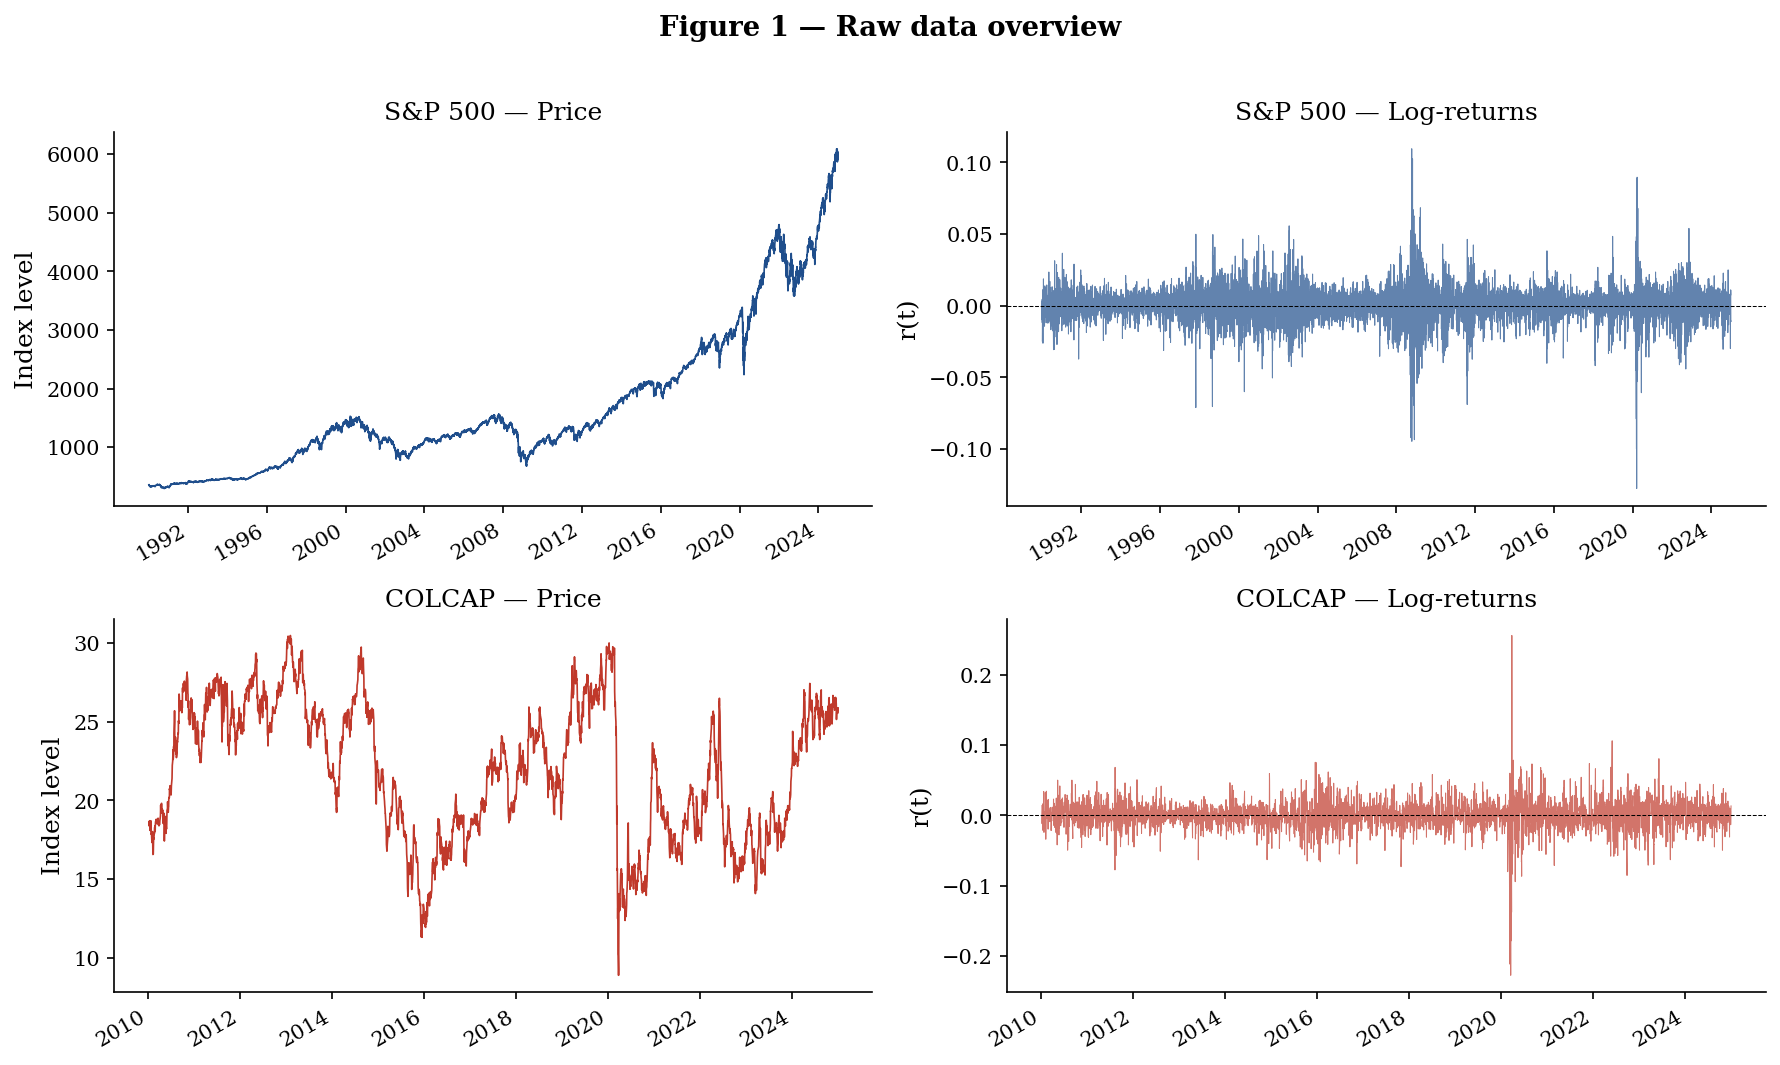


--- Return statistics ---

SP500
  Mean daily return : 8.00% annualized
  Volatility        : 18.06% annualized
  Skewness          : -0.399
  Kurtosis (excess) : 10.676

COLCAP
  Mean daily return : 2.28% annualized
  Volatility        : 32.62% annualized
  Skewness          : -0.378
  Kurtosis (excess) : 17.665


In [7]:
# --- Log-returns ---
returns = {name: np.log(p / p.shift(1)).dropna() for name, p in raw.items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for i, (name, color) in enumerate(zip(['sp500', 'colcap'], [COLORS['sp500'], COLORS['colcap']])):
    label = 'S&P 500' if name == 'sp500' else 'COLCAP'

    # Price
    ax = axes[i, 0]
    raw[name].plot(ax=ax, color=color, lw=0.8)
    ax.set_title(f'{label} — Price')
    ax.set_ylabel('Index level')
    ax.set_xlabel('')

    # Returns
    ax = axes[i, 1]
    returns[name].plot(ax=ax, color=color, lw=0.5, alpha=0.7)
    ax.set_title(f'{label} — Log-returns')
    ax.set_ylabel('r(t)')
    ax.set_xlabel('')
    ax.axhline(0, color='k', lw=0.5, ls='--')

plt.suptitle('Figure 1 — Raw data overview', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGDIR}fig01_raw_data.pdf', bbox_inches='tight')
plt.show()

# Basic statistics
print('\n--- Return statistics ---')
for name in ['sp500', 'colcap']:
    r = returns[name]
    print(f"\n{name.upper()}")
    print(f"  Mean daily return : {r.mean()*252:.2%} annualized")
    print(f"  Volatility        : {r.std()*np.sqrt(252):.2%} annualized")
    print(f"  Skewness          : {r.skew():.3f}")
    print(f"  Kurtosis (excess) : {r.kurtosis():.3f}")

## 2. Drawdown Process Construction

**Definition** (relative drawdown, normalized by local volatility):  
$$D(t) = \frac{\max_{s \leq t} P(s) - P(t)}{\sigma_{\text{local}}(t)}$$

Raw absolute drawdown:
$$D_{\text{abs}}(t) = \max_{s \leq t} P(s) - P(t)$$

The normalized version collapses cross-market scale differences — key for universality claim.

In [8]:
def compute_drawdown(prices, vol_window=21, normalize=True):
    """
    Compute drawdown process D(t).

    Parameters
    ----------
    prices     : pd.Series of prices
    vol_window : rolling window (days) for local volatility normalization
    normalize  : if True, divide by local volatility (relative drawdown)

    Returns
    -------
    dd  : pd.Series — drawdown process
    hwm : pd.Series — running high-water mark
    """
    hwm = prices.cummax()                        # high-water mark
    dd_abs = (hwm - prices) / hwm               # fractional drawdown

    if normalize:
        log_ret = np.log(prices / prices.shift(1))
        local_vol = log_ret.rolling(vol_window, min_periods=5).std() * np.sqrt(252)
        local_vol = local_vol.replace(0, np.nan).ffill().bfill()
        dd = dd_abs / local_vol
    else:
        dd = dd_abs

    return dd.dropna(), hwm


def extract_drawdown_episodes(prices, threshold=0.05, vol_window=21):
    """
    Identify drawdown episodes exceeding threshold (fractional).

    Returns list of dicts with:
        start, peak, trough, end, depth, duration, recovery_time
    """
    hwm = prices.cummax()
    dd_frac = (hwm - prices) / hwm

    episodes = []
    in_dd = False
    peak_idx = None
    peak_val = None

    for i, (idx, val) in enumerate(dd_frac.items()):
        if not in_dd:
            if val >= threshold:
                in_dd = True
                # backtrack to find the peak
                peak_pos = prices[:idx].idxmax()
                peak_idx = peak_pos
                peak_val = prices[peak_pos]
        else:
            if val < threshold * 0.1:  # recovered to within 10% of threshold
                recovery_idx = idx
                trough_pos = dd_frac[peak_idx:recovery_idx].idxmax()
                depth = dd_frac[trough_pos]

                if depth >= threshold:
                    duration = (trough_pos - peak_idx).days
                    recovery = (recovery_idx - trough_pos).days
                    episodes.append({
                        'peak': peak_idx,
                        'trough': trough_pos,
                        'recovery': recovery_idx,
                        'depth': depth,
                        'duration_days': duration,
                        'recovery_days': recovery,
                    })
                in_dd = False

    return pd.DataFrame(episodes)


# --- Compute drawdowns ---
drawdowns = {}
episodes  = {}

for name in ['sp500', 'colcap']:
    dd, hwm = compute_drawdown(raw[name], normalize=True)
    drawdowns[name] = dd
    ep = extract_drawdown_episodes(raw[name], threshold=0.05)
    episodes[name] = ep
    print(f"{name.upper()}: {len(ep)} drawdown episodes (>5% threshold)")
    if len(ep):
        print(f"  Median depth    : {ep['depth'].median():.1%}")
        print(f"  Median duration : {ep['duration_days'].median():.0f} trading days")
        print(f"  Median recovery : {ep['recovery_days'].median():.0f} trading days")

SP500: 37 drawdown episodes (>5% threshold)
  Median depth    : 8.5%
  Median duration : 32 trading days
  Median recovery : 41 trading days
COLCAP: 6 drawdown episodes (>5% threshold)
  Median depth    : 16.1%
  Median duration : 60 trading days
  Median recovery : 81 trading days


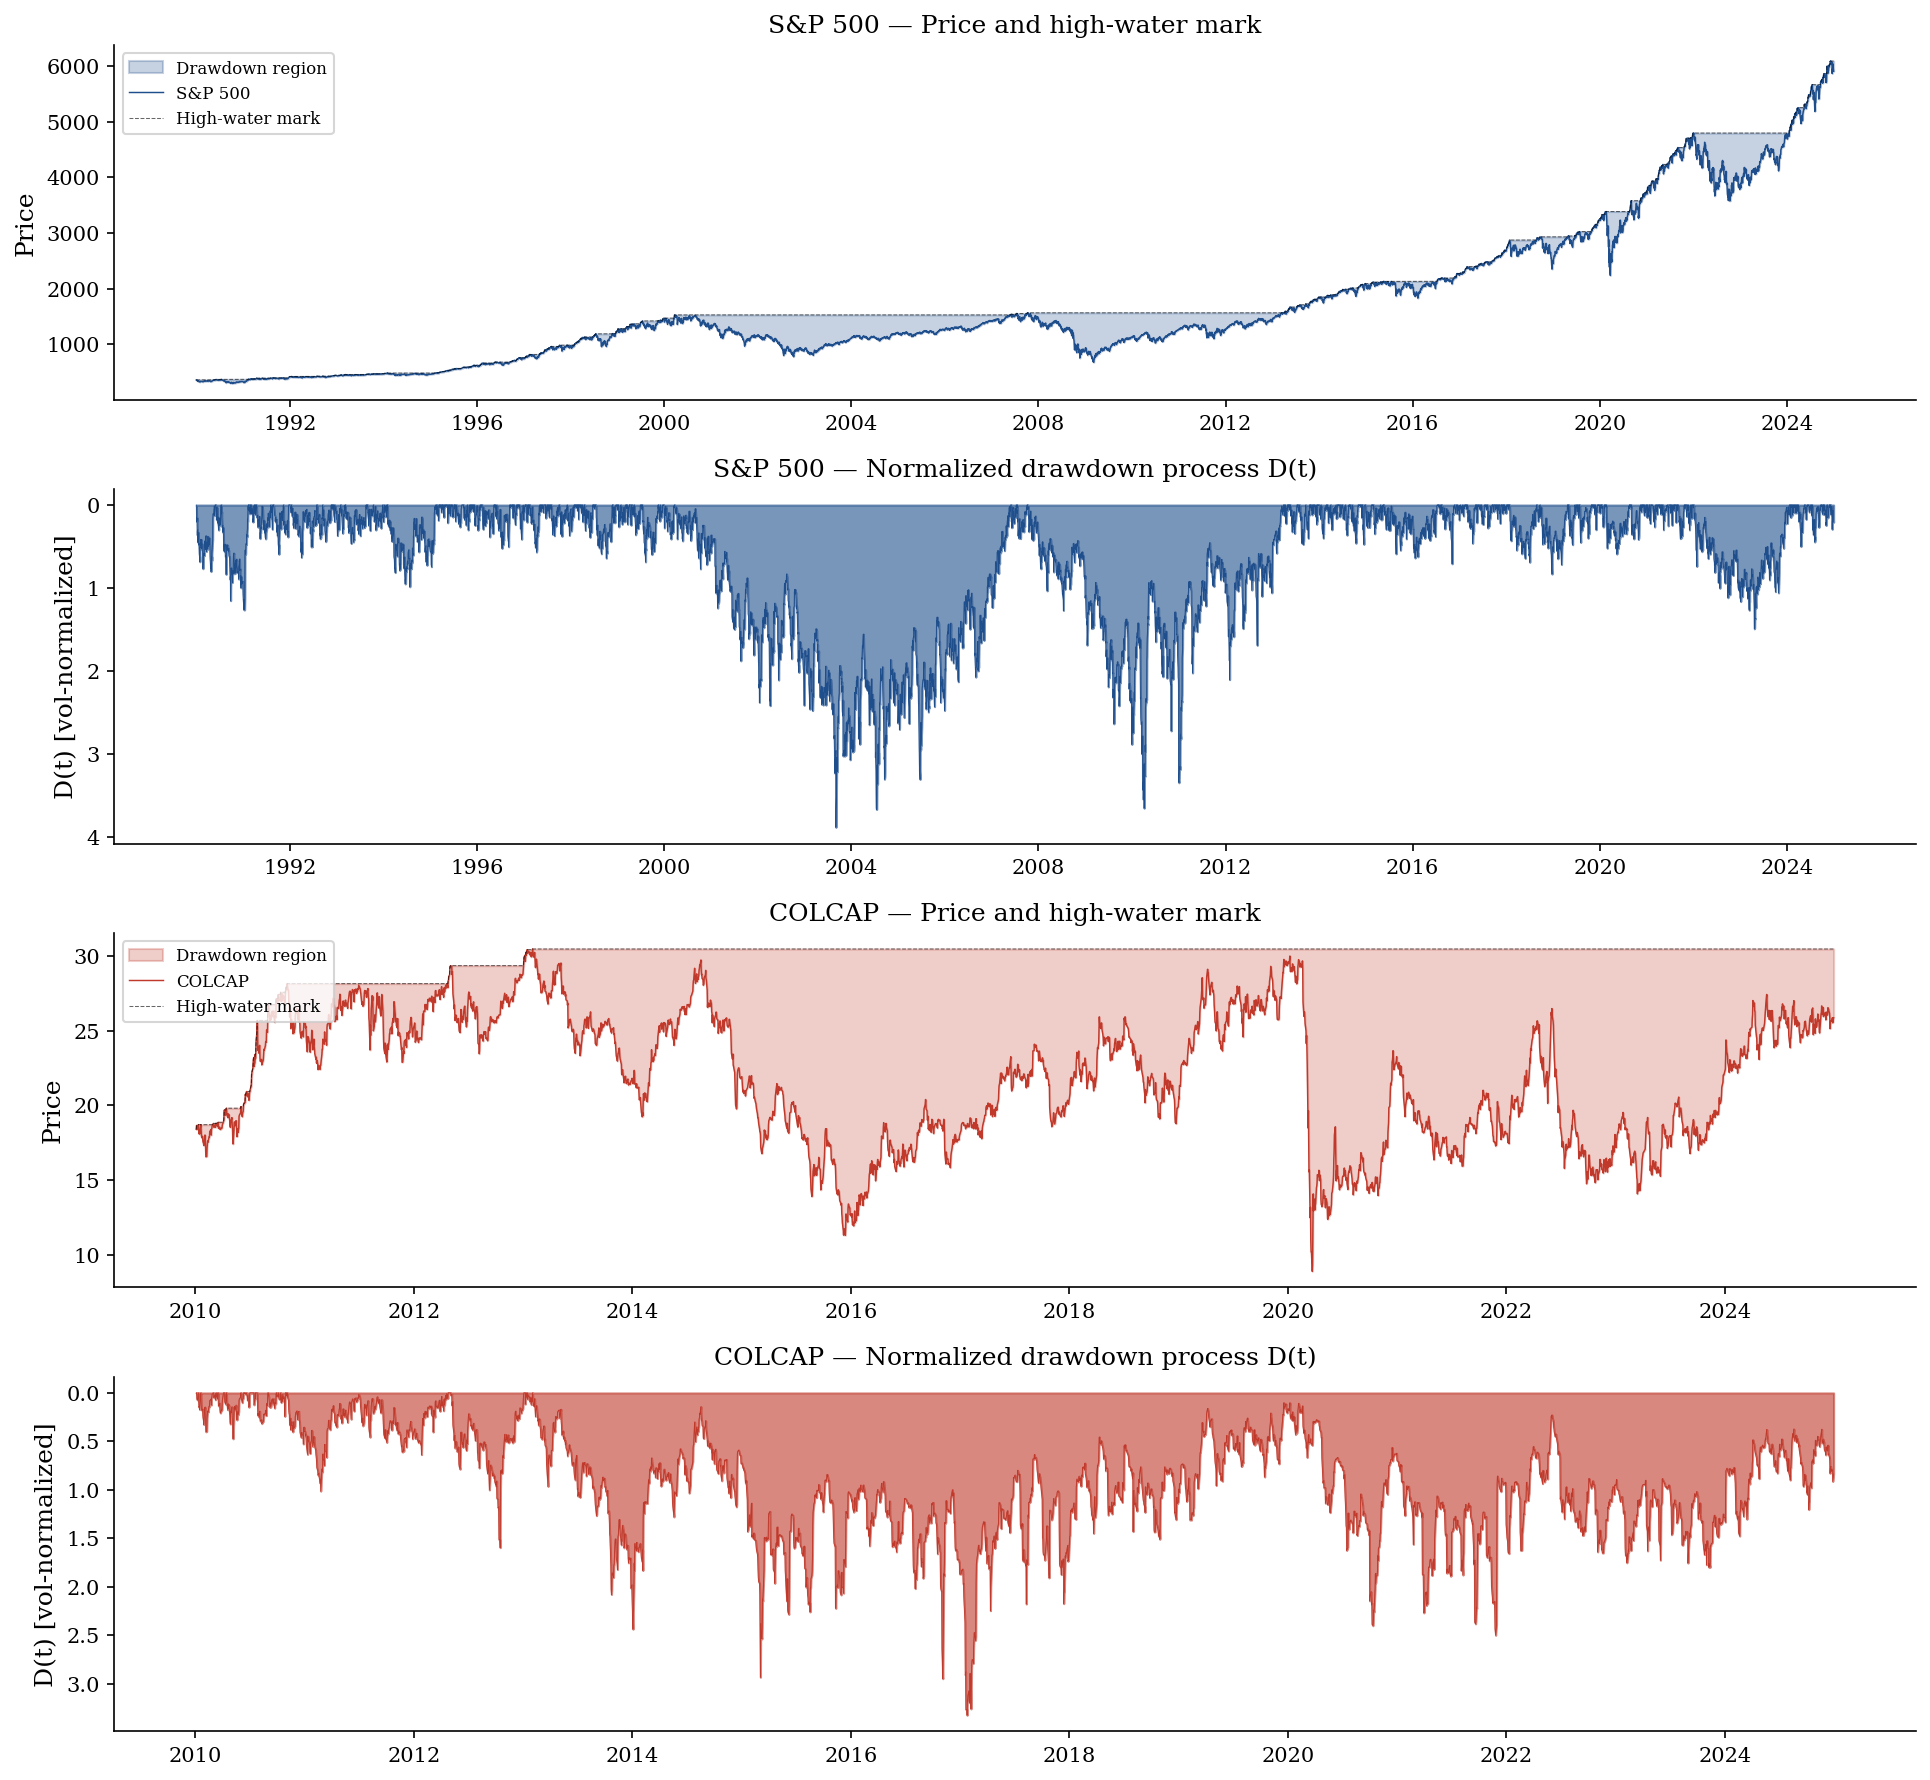

In [9]:
# --- Figure 2: Drawdown process visualization ---
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=False)

for i, (name, color, label) in enumerate(zip(
        ['sp500', 'colcap'],
        [COLORS['sp500'], COLORS['colcap']],
        ['S&P 500', 'COLCAP'])):

    ax1 = axes[2*i]
    ax2 = axes[2*i + 1]

    # Price with HWM
    p = raw[name]
    hwm = p.cummax()
    ax1.fill_between(p.index, p, hwm, alpha=0.25, color=color, label='Drawdown region')
    ax1.plot(p.index, p, color=color, lw=0.7, label=label)
    ax1.plot(hwm.index, hwm, color='k', lw=0.5, ls='--', alpha=0.6, label='High-water mark')
    ax1.set_ylabel('Price')
    ax1.set_title(f'{label} — Price and high-water mark')
    ax1.legend(loc='upper left', fontsize=8)

    # Drawdown process
    dd = drawdowns[name]
    ax2.fill_between(dd.index, 0, dd, alpha=0.6, color=color)
    ax2.plot(dd.index, dd, color=color, lw=0.4)
    ax2.set_ylabel('D(t) [vol-normalized]')
    ax2.set_title(f'{label} — Normalized drawdown process D(t)')
    ax2.invert_yaxis()   # drawdown positive downward (convention)

plt.tight_layout()
plt.savefig(f'{FIGDIR}fig02_drawdown_process.pdf', bbox_inches='tight')
plt.show()

## 3. Kramers–Moyal Coefficient Estimation

Estimate the drift $D^{(1)}(x)$ and diffusion $D^{(2)}(x)$ from the drawdown increments:

$$D^{(n)}(x) = \frac{1}{n! \, \tau} \langle (X(t+\tau) - X(t))^n \mid X(t) = x \rangle$$

Test for Pawula's theorem: if $D^{(4)} \approx 0$, the process is Markovian and the Fokker–Planck description is exact.

SP500: KM estimado sobre 8089 observaciones D(t) > 0
COLCAP: KM estimado sobre 3716 observaciones D(t) > 0

KM estimation complete.


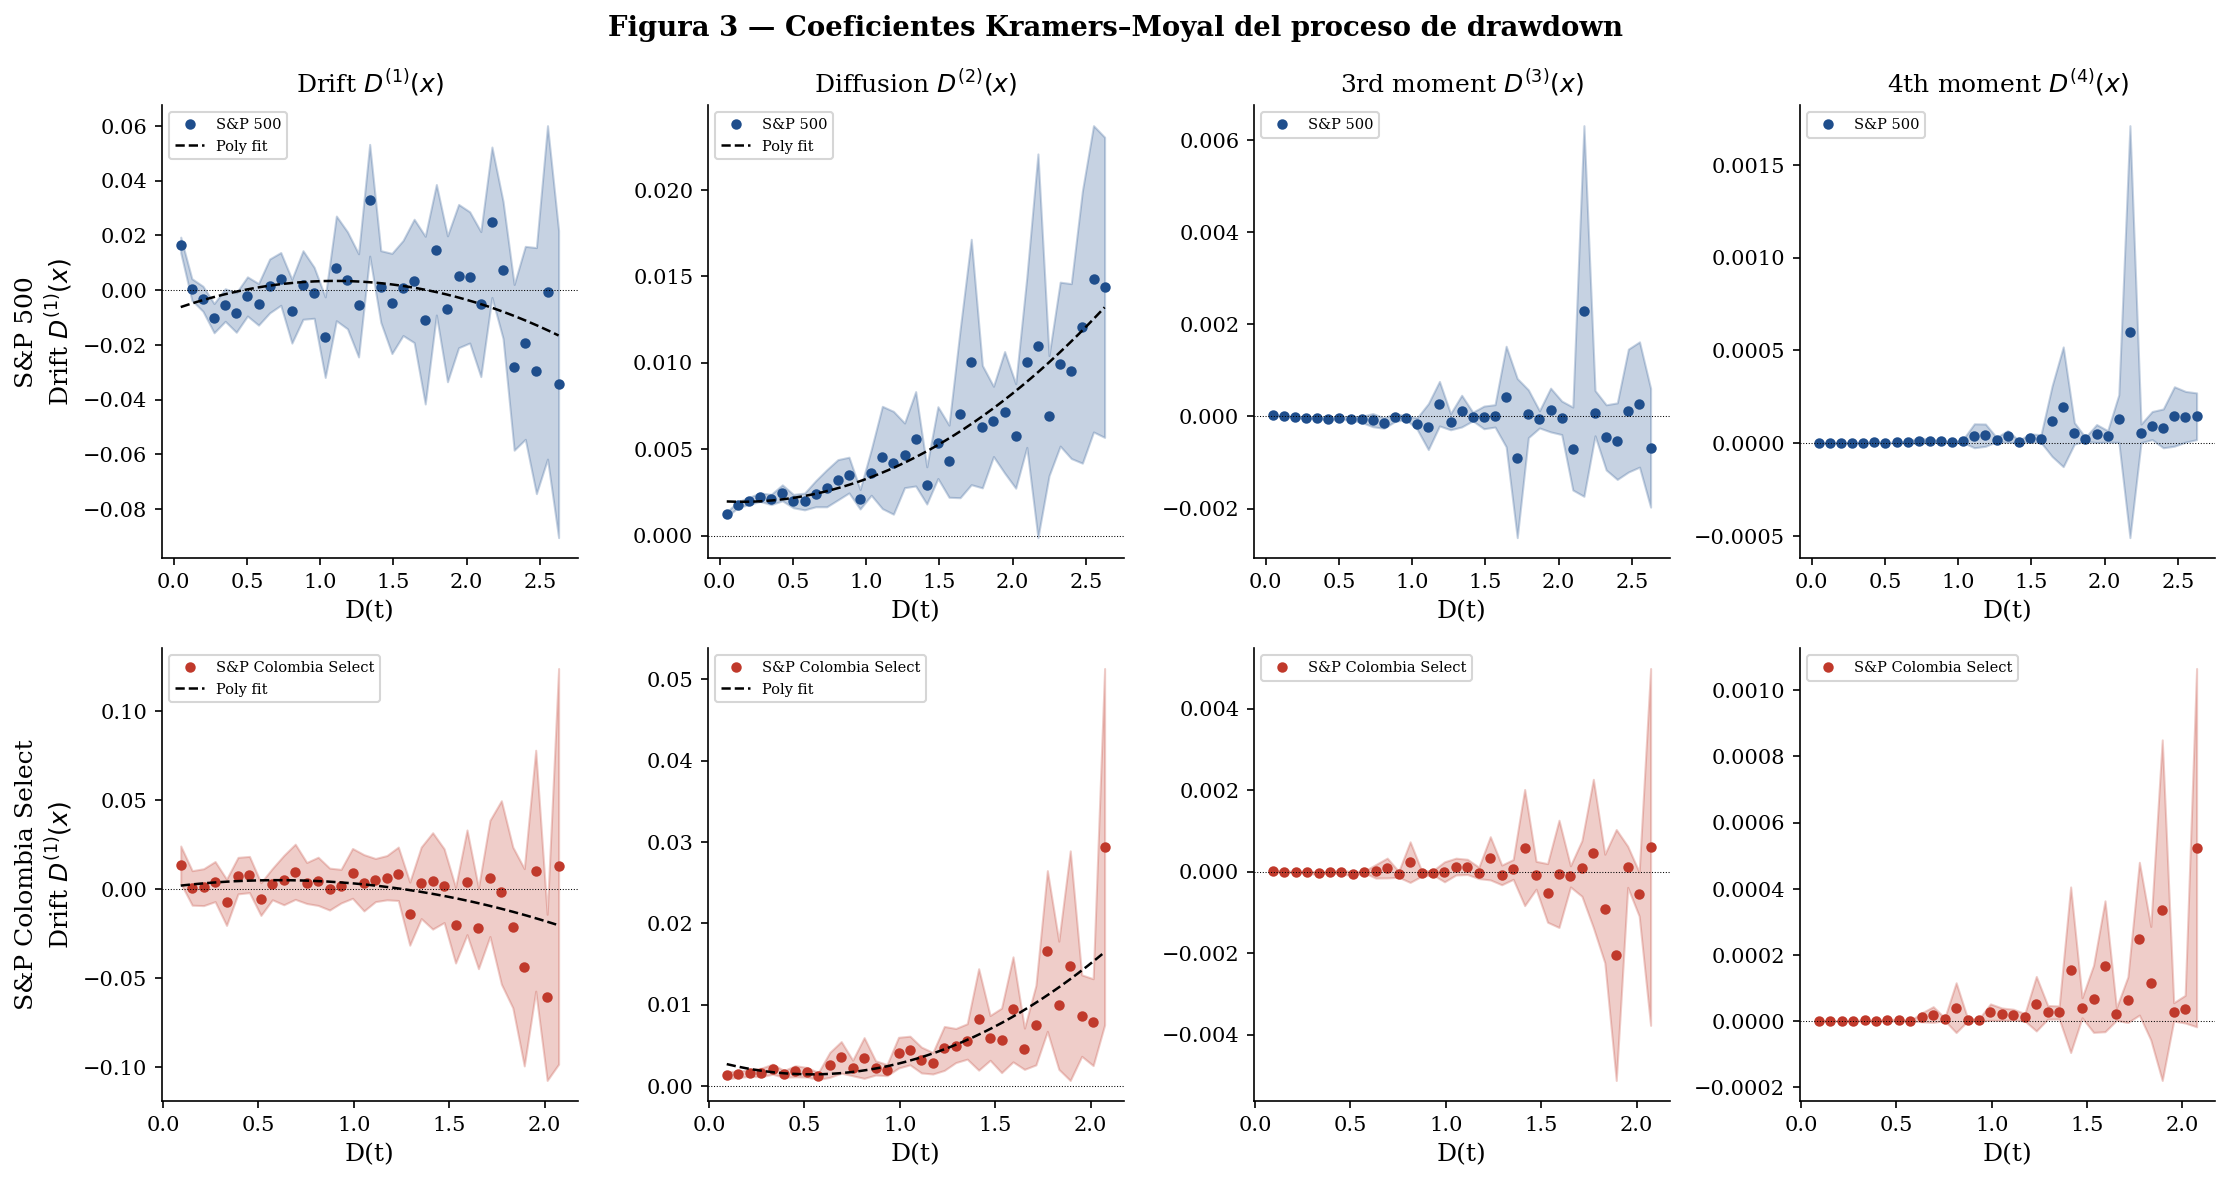

In [11]:
from math import factorial

def kramers_moyal(x, tau=1, n_bins=40, max_order=4):
    """
    Estimate Kramers-Moyal coefficients D^(n)(x) from a 1D time series.

    Parameters
    ----------
    x         : array-like, the process (drawdown values)
    tau       : int, time lag (in steps)
    n_bins    : number of bins for conditional expectation
    max_order : highest KM order to compute

    Returns
    -------
    bin_centers : array of x values
    km          : dict {order: coefficient array}
    km_err      : dict {order: bootstrap std array}
    """
    x = np.asarray(x)
    dx = x[tau:] - x[:-tau]
    xc = x[:-tau]

    lo, hi = np.percentile(xc, 2), np.percentile(xc, 98)
    edges   = np.linspace(lo, hi, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    km     = {n: np.full(n_bins, np.nan) for n in range(1, max_order + 1)}
    km_err = {n: np.full(n_bins, np.nan) for n in range(1, max_order + 1)}

    for j in range(n_bins):
        mask = (xc >= edges[j]) & (xc < edges[j+1])
        if mask.sum() < 15:
            continue
        dxj = dx[mask]
        for n in range(1, max_order + 1):
            moment       = np.mean(dxj**n) / (factorial(n) * tau)
            km[n][j]     = moment
            km_err[n][j] = np.std(dxj**n) / (factorial(n) * tau * np.sqrt(mask.sum()))

    return centers, km, km_err


# --- Run KM estimation ---
km_results = {}

for name in MARKETS:
    dd     = drawdowns[name].values
    dd_pos = dd[dd > 0]
    centers, km, km_err = kramers_moyal(dd_pos, tau=1, n_bins=35, max_order=4)
    km_results[name] = {'centers': centers, 'km': km, 'km_err': km_err}
    print(f"{name.upper()}: KM estimado sobre {len(dd_pos)} observaciones D(t) > 0")

print('\nKM estimation complete.')


# --- Figura 3: KM coefficients ---
order_labels = {
    1: r'Drift $D^{(1)}(x)$',
    2: r'Diffusion $D^{(2)}(x)$',
    3: r'3rd moment $D^{(3)}(x)$',
    4: r'4th moment $D^{(4)}(x)$',
}

fig, axes = plt.subplots(len(MARKETS), 4, figsize=(15, 4 * len(MARKETS)))
if len(MARKETS) == 1:
    axes = axes[np.newaxis, :]

for i, name in enumerate(MARKETS):
    color = COLORS['sp500'] if name == 'sp500' else COLORS['colcap']
    label = LABELS[name]
    res   = km_results[name]
    x     = res['centers']

    for j, order in enumerate([1, 2, 3, 4]):
        ax = axes[i, j]
        y  = res['km'][order]
        ye = res['km_err'][order]

        valid = ~np.isnan(y)
        ax.plot(x[valid], y[valid], 'o', color=color, ms=4, label=label)
        ax.fill_between(x[valid],
                        y[valid] - 2*ye[valid],
                        y[valid] + 2*ye[valid],
                        alpha=0.25, color=color)

        # Polynomial fit for D1 and D2
        if order in [1, 2] and valid.sum() > 5:
            xv, yv = x[valid], y[valid]
            try:
                p    = np.polyfit(xv, yv, 2)
                xfit = np.linspace(xv.min(), xv.max(), 200)
                ax.plot(xfit, np.polyval(p, xfit), '--', color='k', lw=1.2,
                        label='Poly fit')
            except Exception:
                pass

        ax.axhline(0, color='k', lw=0.5, ls=':')
        ax.set_xlabel('D(t)')
        if i == 0:
            ax.set_title(order_labels[order])
        if j == 0:
            ax.set_ylabel(f'{label}\n{order_labels[1]}')
        ax.legend(fontsize=7)

plt.suptitle('Figura 3 — Coeficientes Kramers–Moyal del proceso de drawdown',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}fig03_km_coefficients.pdf', bbox_inches='tight')
plt.show()

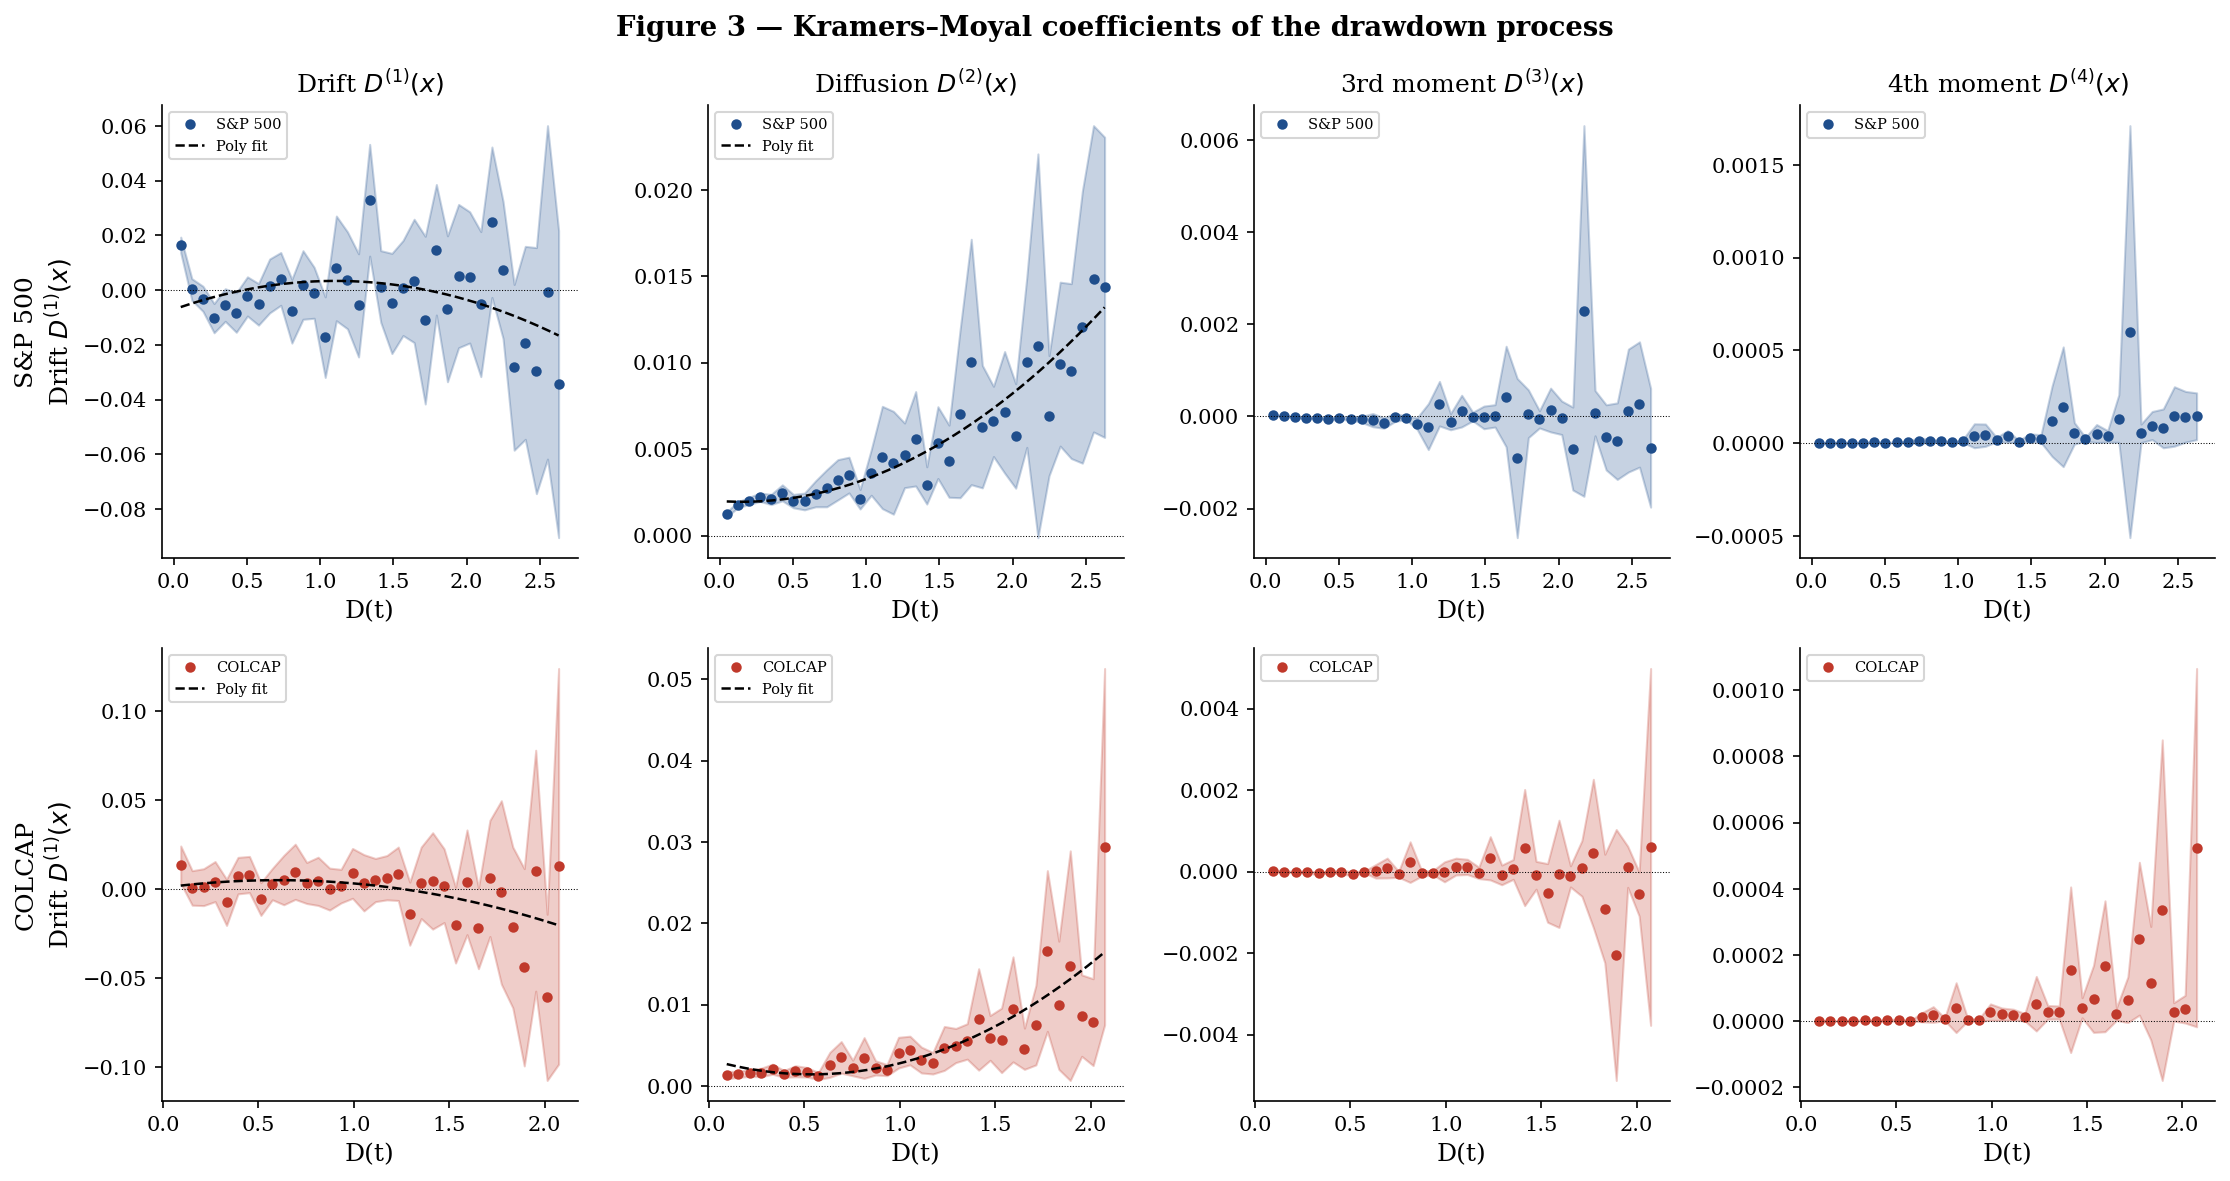

In [12]:
# --- Figure 3: KM coefficients ---
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

order_labels = {
    1: r'Drift $D^{(1)}(x)$',
    2: r'Diffusion $D^{(2)}(x)$',
    3: r'3rd moment $D^{(3)}(x)$',
    4: r'4th moment $D^{(4)}(x)$',
}

for i, (name, color, label) in enumerate(zip(
        ['sp500', 'colcap'],
        [COLORS['sp500'], COLORS['colcap']],
        ['S&P 500', 'COLCAP'])):

    res = km_results[name]
    x   = res['centers']

    for j, order in enumerate([1, 2, 3, 4]):
        ax = axes[i, j]
        y  = res['km'][order]
        ye = res['km_err'][order]

        valid = ~np.isnan(y)
        ax.plot(x[valid], y[valid], 'o', color=color, ms=4, label=label)
        ax.fill_between(x[valid],
                        y[valid] - 2*ye[valid],
                        y[valid] + 2*ye[valid],
                        alpha=0.25, color=color)

        # Fit polynomial for D1 and D2
        if order in [1, 2] and valid.sum() > 5:
            deg = 2 if order == 1 else 2
            xv, yv = x[valid], y[valid]
            try:
                p = np.polyfit(xv, yv, deg)
                xfit = np.linspace(xv.min(), xv.max(), 200)
                ax.plot(xfit, np.polyval(p, xfit), '--', color='k', lw=1.2, label='Poly fit')
            except Exception:
                pass

        ax.axhline(0, color='k', lw=0.5, ls=':')
        ax.set_xlabel('D(t)')
        ax.set_ylabel(order_labels[order] if j == 0 else '')
        if i == 0:
            ax.set_title(order_labels[order])
        if j == 0:
            ax.set_ylabel(f'{label}\n{order_labels[order]}')
        ax.legend(fontsize=7)

plt.suptitle('Figure 3 — Kramers–Moyal coefficients of the drawdown process', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}fig03_km_coefficients.pdf', bbox_inches='tight')
plt.show()

## 4. Fokker–Planck / Langevin Validation

Fit the Langevin equation:
$$dD = D^{(1)}(D)\,dt + \sqrt{2 D^{(2)}(D)}\,dW$$

Validate by integrating the Fokker–Planck equation and comparing the stationary distribution $p_s(D)$ with the empirical histogram.

In [13]:
def fit_km_polynomial(centers, km, order, degree=2):
    """
    Fit a polynomial to a KM coefficient array.
    Returns the polynomial as a callable.
    """
    x = centers
    y = km[order]
    valid = ~np.isnan(y)
    if valid.sum() < degree + 2:
        raise ValueError("Not enough valid points for polynomial fit.")
    coeffs = np.polyfit(x[valid], y[valid], degree)
    return np.poly1d(coeffs), coeffs


def fokker_planck_stationary(x_grid, D1_fn, D2_fn):
    """
    Compute stationary distribution of the Fokker–Planck equation:
        p_s(x) ∝ (1/D2(x)) * exp(integral of D1(x)/D2(x) dx)
    Using the potential U(x) = -integral(D1/D2 dx).
    """
    dx = x_grid[1] - x_grid[0]
    ratio = D1_fn(x_grid) / (D2_fn(x_grid) + 1e-12)
    # Numerical integration
    integral = np.cumsum(ratio) * dx
    D2_vals  = D2_fn(x_grid)
    # Avoid division by zero
    D2_vals = np.where(np.abs(D2_vals) < 1e-12, 1e-12, D2_vals)
    ps = np.exp(integral) / D2_vals
    ps = np.where(ps < 0, 0, ps)
    # Normalize
    norm = np.trapz(ps, x_grid)
    if norm > 0:
        ps /= norm
    return ps


def simulate_langevin(D1_fn, D2_fn, x0, n_steps=50000, dt=1.0, seed=42):
    """
    Euler–Maruyama integration of the Langevin SDE:
        X_{t+1} = X_t + D1(X_t)*dt + sqrt(2*D2(X_t)*dt)*xi
    with reflecting boundary at x=0.
    """
    rng = np.random.default_rng(seed)
    x = np.zeros(n_steps)
    x[0] = x0
    for i in range(1, n_steps):
        xi = rng.standard_normal()
        d1 = D1_fn(x[i-1])
        d2 = max(D2_fn(x[i-1]), 1e-12)
        x[i] = x[i-1] + d1 * dt + np.sqrt(2 * d2 * dt) * xi
        if x[i] < 0:
            x[i] = -x[i]   # reflecting BC at D=0
    return x


# --- Fit and validate ---
langevin_fits = {}

for name in ['sp500', 'colcap']:
    res = km_results[name]
    x_c = res['centers']

    D1_poly, D1_coeffs = fit_km_polynomial(x_c, res['km'], order=1, degree=2)
    D2_poly, D2_coeffs = fit_km_polynomial(x_c, res['km'], order=2, degree=2)

    # Ensure D2 > 0 by clamping
    D2_safe = lambda x, fn=D2_poly: np.maximum(fn(x), 1e-4)

    langevin_fits[name] = {
        'D1': D1_poly, 'D1_coeffs': D1_coeffs,
        'D2': D2_safe,  'D2_coeffs': D2_coeffs,
    }

    print(f"{name.upper()}")
    print(f"  D1(x) = {D1_coeffs[0]:.4f}x² + {D1_coeffs[1]:.4f}x + {D1_coeffs[2]:.4f}")
    print(f"  D2(x) = {D2_coeffs[0]:.4f}x² + {D2_coeffs[1]:.4f}x + {D2_coeffs[2]:.4f}")

print('\nLangevin fits complete.')

SP500
  D1(x) = -0.0086x² + 0.0190x + -0.0071
  D2(x) = 0.0018x² + -0.0006x + 0.0020
COLCAP
  D1(x) = -0.0117x² + 0.0141x + 0.0009
  D2(x) = 0.0064x² + -0.0068x + 0.0033

Langevin fits complete.


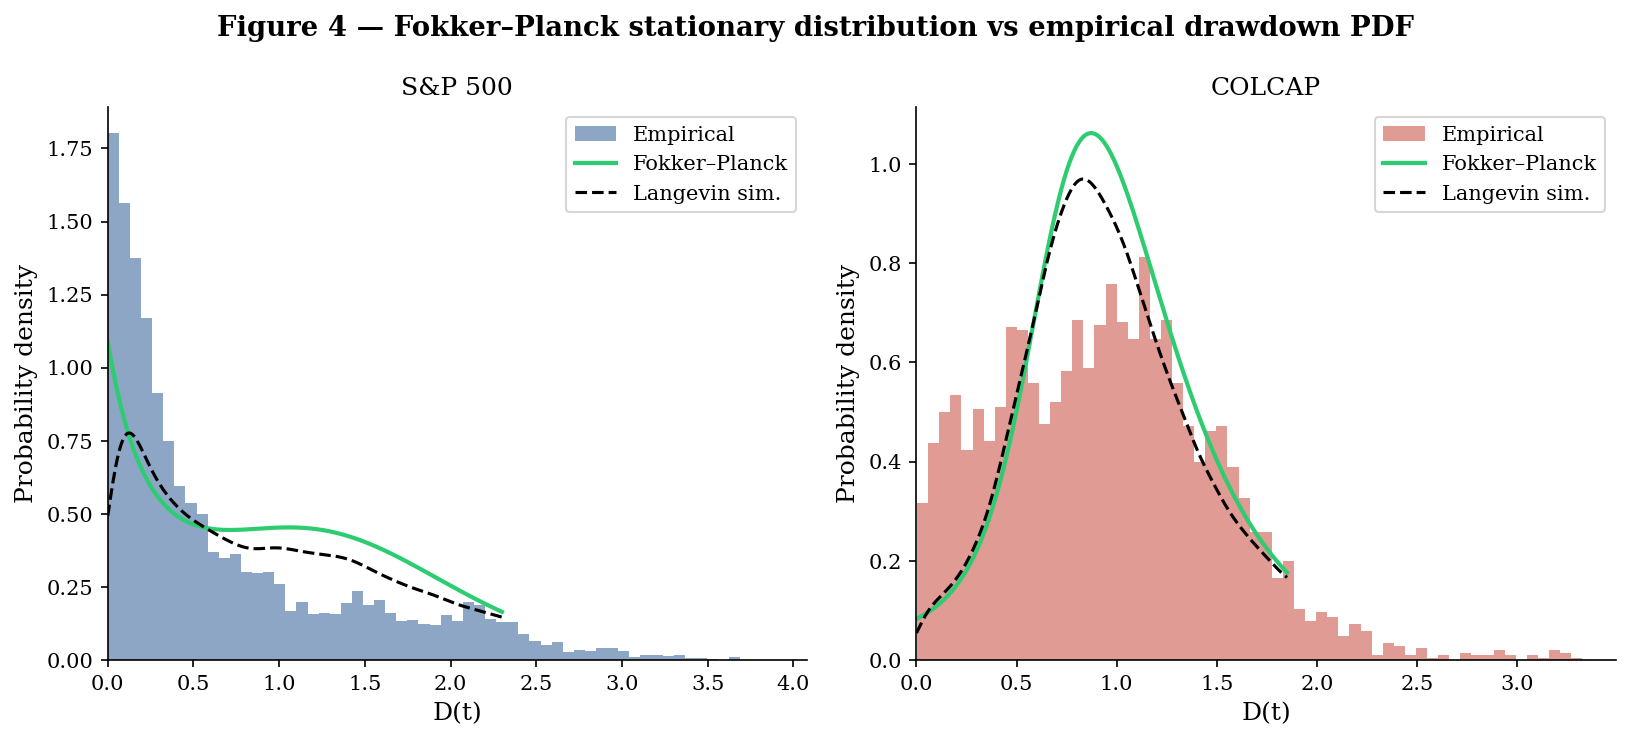

In [14]:
# --- Figure 4: Fokker–Planck stationary distribution vs empirical ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (name, color, label) in zip(axes, [
        ('sp500',  COLORS['sp500'],  'S&P 500'),
        ('colcap', COLORS['colcap'], 'COLCAP')]):

    dd = drawdowns[name].values
    dd_pos = dd[dd > 0]

    x_grid = np.linspace(0, np.percentile(dd_pos, 95), 300)
    fit = langevin_fits[name]

    # Empirical PDF
    ax.hist(dd_pos, bins=60, density=True, alpha=0.5, color=color, label='Empirical')

    # Fokker–Planck stationary
    ps = fokker_planck_stationary(x_grid, fit['D1'], fit['D2'])
    ax.plot(x_grid, ps, '-', color=COLORS['theory'], lw=2, label='Fokker–Planck')

    # Langevin simulation
    x_sim = simulate_langevin(fit['D1'], fit['D2'], x0=dd_pos.mean(), n_steps=80000)
    x_sim_pos = x_sim[x_sim > 0]
    kde = stats.gaussian_kde(x_sim_pos)
    ax.plot(x_grid, kde(x_grid), '--', color='k', lw=1.5, label='Langevin sim.')

    ax.set_xlabel('D(t)')
    ax.set_ylabel('Probability density')
    ax.set_title(f'{label}')
    ax.legend()
    ax.set_xlim(left=0)

plt.suptitle('Figure 4 — Fokker–Planck stationary distribution vs empirical drawdown PDF',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}fig04_fokker_planck.pdf', bbox_inches='tight')
plt.show()

## 5. First-Passage Time Distributions

**Two first-passage times of interest:**

1. **Drawdown duration** $T^*$: time from peak to trough (first passage of D(t) to level $\theta$)  
2. **Recovery time** $T_R$: time from trough back to the high-water mark (D = 0)

Both should exhibit heavy-tailed distributions if the underlying process is Langevin.

In [22]:
def extract_fpt_exceedances(prices, thresholds, vol_window=21):
    """
    Estrategia alternativa: mide el tiempo que D(t) pasa
    continuamente por encima de cada umbral θ (run lengths).
    Produce N >> episodios completos.
    """
    p       = prices.squeeze()
    hwm     = p.cummax()
    dd_frac = ((hwm - p) / hwm).fillna(0).values

    fp_times  = {th: [] for th in thresholds}
    rec_times = {th: [] for th in thresholds}

    for th in thresholds:
        above = dd_frac >= th
        # Run-length encoding
        i = 0
        while i < len(above):
            if above[i]:
                # inicio de exceedance
                start = i
                while i < len(above) and above[i]:
                    i += 1
                run_len = i - start
                fp_times[th].append(run_len)
                # tiempo hasta próxima exceedance (inter-arrival)
                j = i
                while j < len(above) and not above[j]:
                    j += 1
                inter = j - i
                if inter > 0:
                    rec_times[th].append(inter)
            else:
                i += 1

    return (
        {th: np.array(v) for th, v in fp_times.items()},
        {th: np.array(v) for th, v in rec_times.items()},
    )


# --- Combinar ambas estrategias ---
# Episodios completos (para MFPT e interpretación)
# Exceedances (para estimación de α con suficiente N)

THRESHOLDS = [0.05, 0.10, 0.15, 0.20]

fpt_exceed = {}
for name in MARKETS:
    fp, rc = extract_fpt_exceedances(raw[name], THRESHOLDS)
    fpt_exceed[name] = {'fpt': fp, 'rec': rc}
    print(f"\n{LABELS[name]} — Exceedance run lengths")
    for th in THRESHOLDS:
        n  = len(fp[th])
        m  = np.mean(fp[th]) if n > 0 else np.nan
        r  = len(rc[th])
        mr = np.mean(rc[th]) if r > 0 else np.nan
        print(f"  θ={th:.2f} | N_runs={n:4d} mean={m:6.1f}d | "
              f"N_inter={r:4d} mean={mr:6.1f}d")


S&P 500 — Exceedance run lengths
  θ=0.05 | N_runs= 120 mean=  36.6d | N_inter= 120 mean=  36.8d
  θ=0.10 | N_runs=  59 mean=  55.3d | N_inter=  59 mean=  93.8d
  θ=0.15 | N_runs=  61 mean=  41.9d | N_inter=  61 mean=  99.9d
  θ=0.20 | N_runs=  41 mean=  44.7d | N_inter=  41 mean= 101.4d

S&P Colombia Select — Exceedance run lengths
  θ=0.05 | N_runs=  37 mean=  90.8d | N_inter=  36 mean=  11.1d
  θ=0.10 | N_runs=  37 mean=  82.2d | N_inter=  36 mean=  19.7d
  θ=0.15 | N_runs=  44 mean=  59.6d | N_inter=  43 mean=  20.8d
  θ=0.20 | N_runs=  28 mean=  77.4d | N_inter=  28 mean=  47.2d


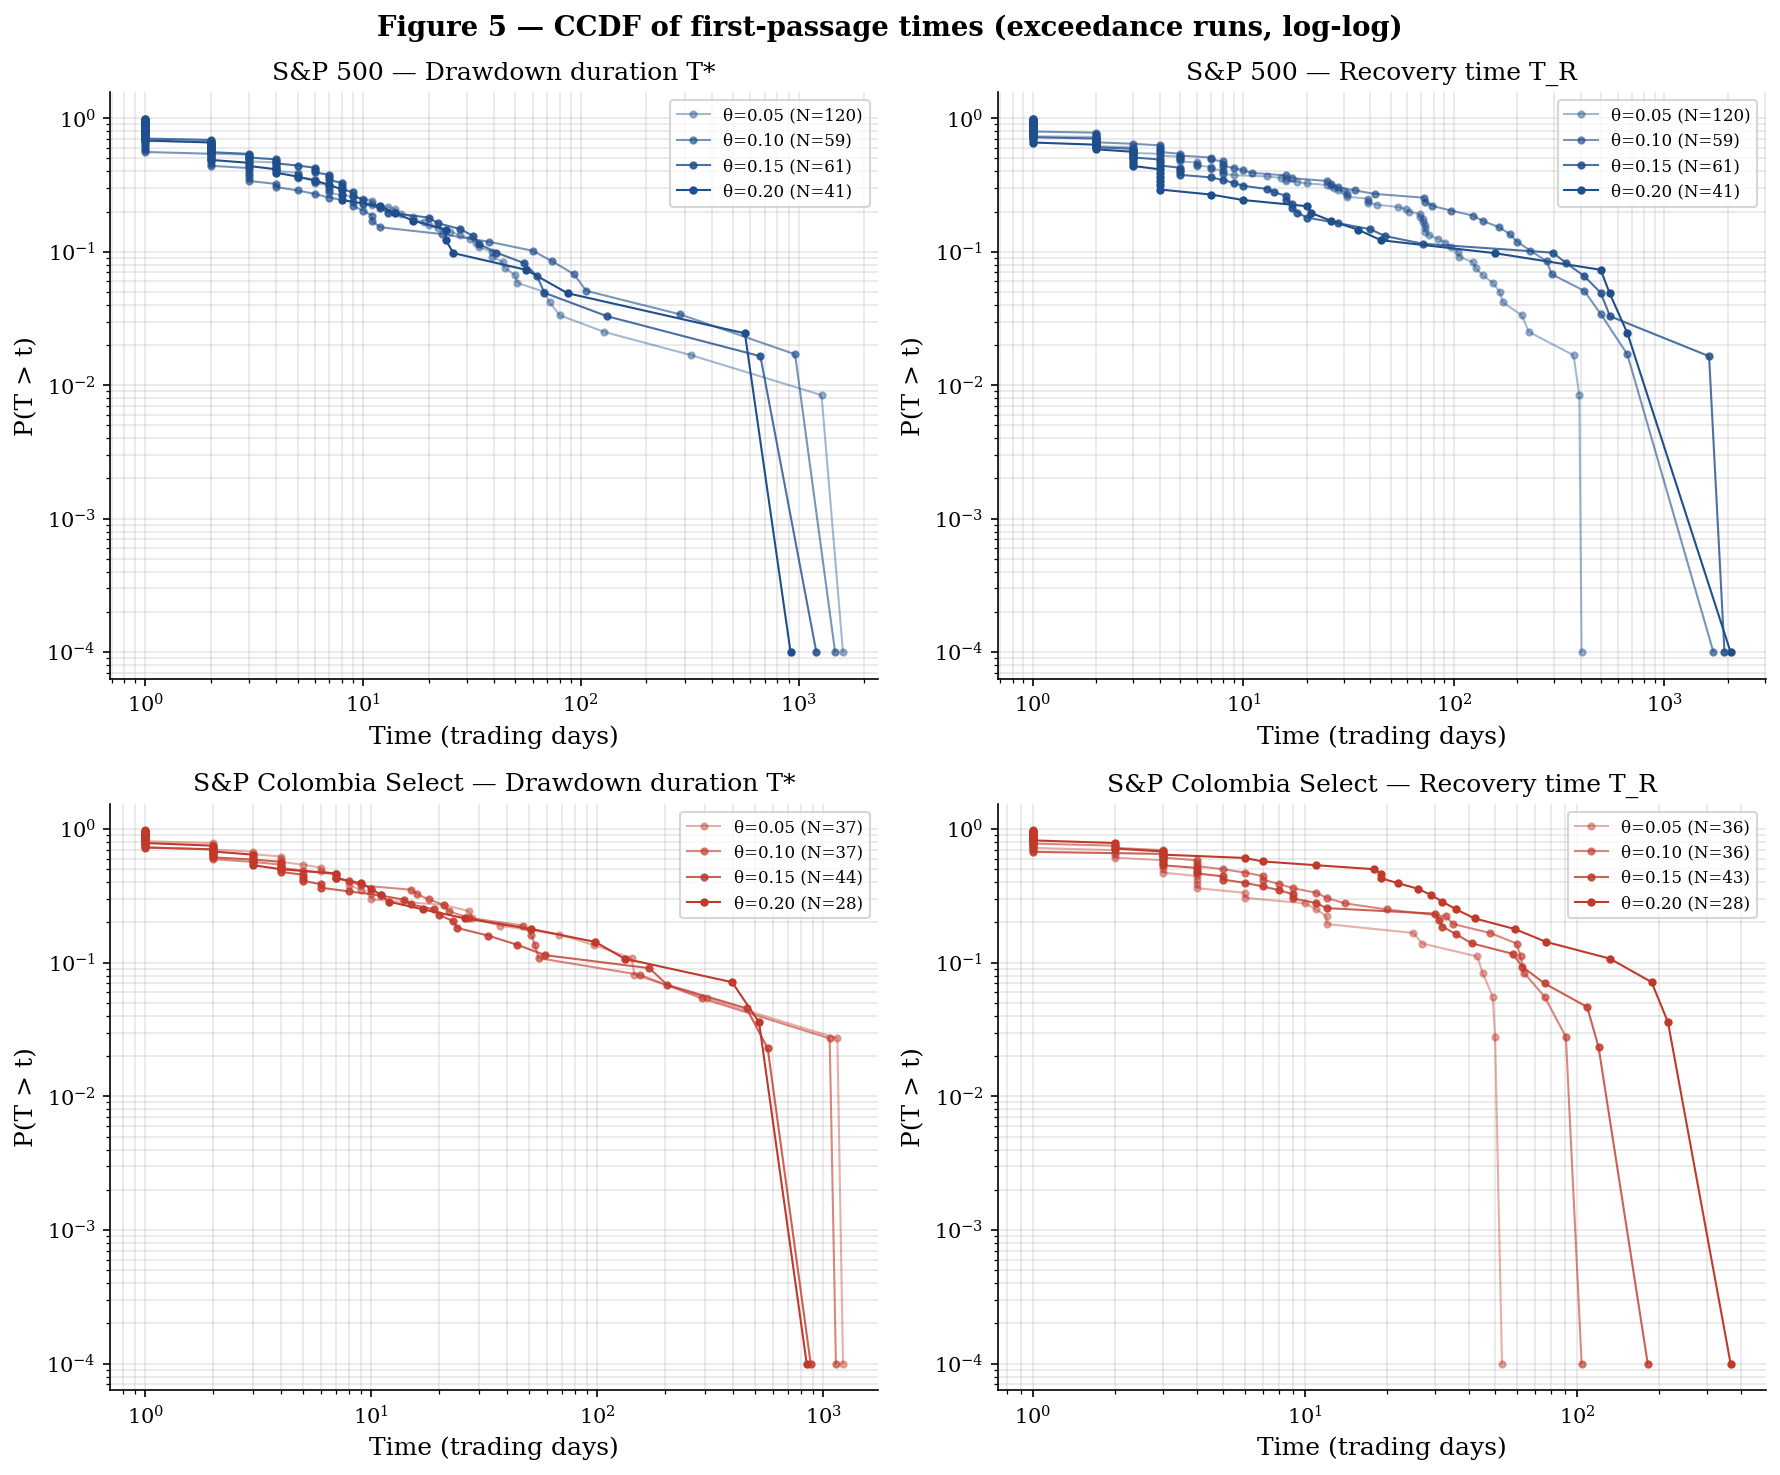

Market               | Type       | θ     | N    | α Hill   | ±σ     | α OLS   | R²   
------------------------------------------------------------------------------
S&P 500              | fpt        |  0.05 |  120 |    0.768 |  0.085 |   1.303 | 0.672
S&P 500              | fpt        |  0.10 |   59 |    0.506 |  0.079 |   1.232 | 0.556
S&P 500              | fpt        |  0.15 |   61 |    0.704 |  0.064 |   1.550 | 0.653
S&P 500              | fpt        |  0.20 |   41 |    0.612 |  0.035 |   1.707 | 0.627
S&P 500              | rec        |  0.05 |  120 |    1.422 |  0.354 |   2.001 | 0.482
S&P 500              | rec        |  0.10 |   59 |    0.971 |  0.256 |   2.179 | 0.573
S&P 500              | rec        |  0.15 |   61 |    0.461 |  0.251 |   1.068 | 0.445
S&P 500              | rec        |  0.20 |   41 |    0.409 |  0.044 |   0.993 | 0.499
S&P Colombia Select  | fpt        |  0.05 |   37 |    0.543 |  0.093 |   1.763 | 0.493
S&P Colombia Select  | fpt        |  0.10 |   37 | 

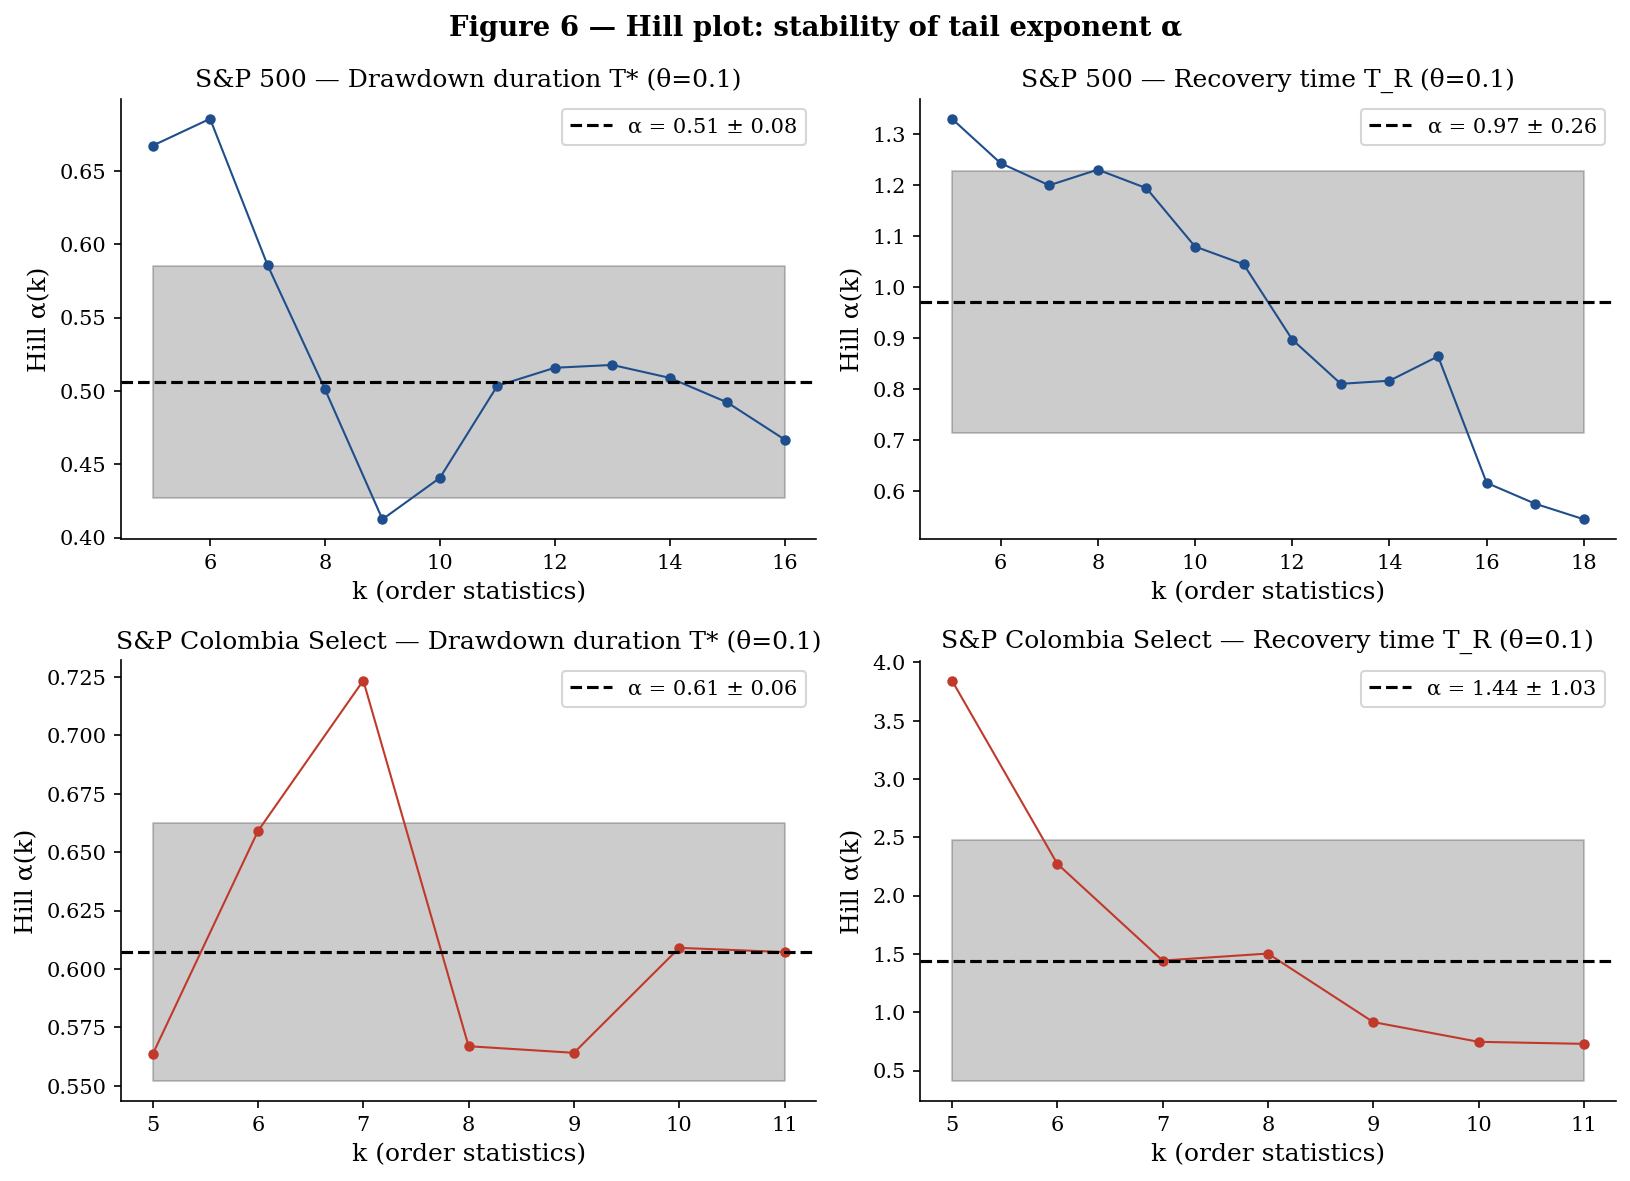

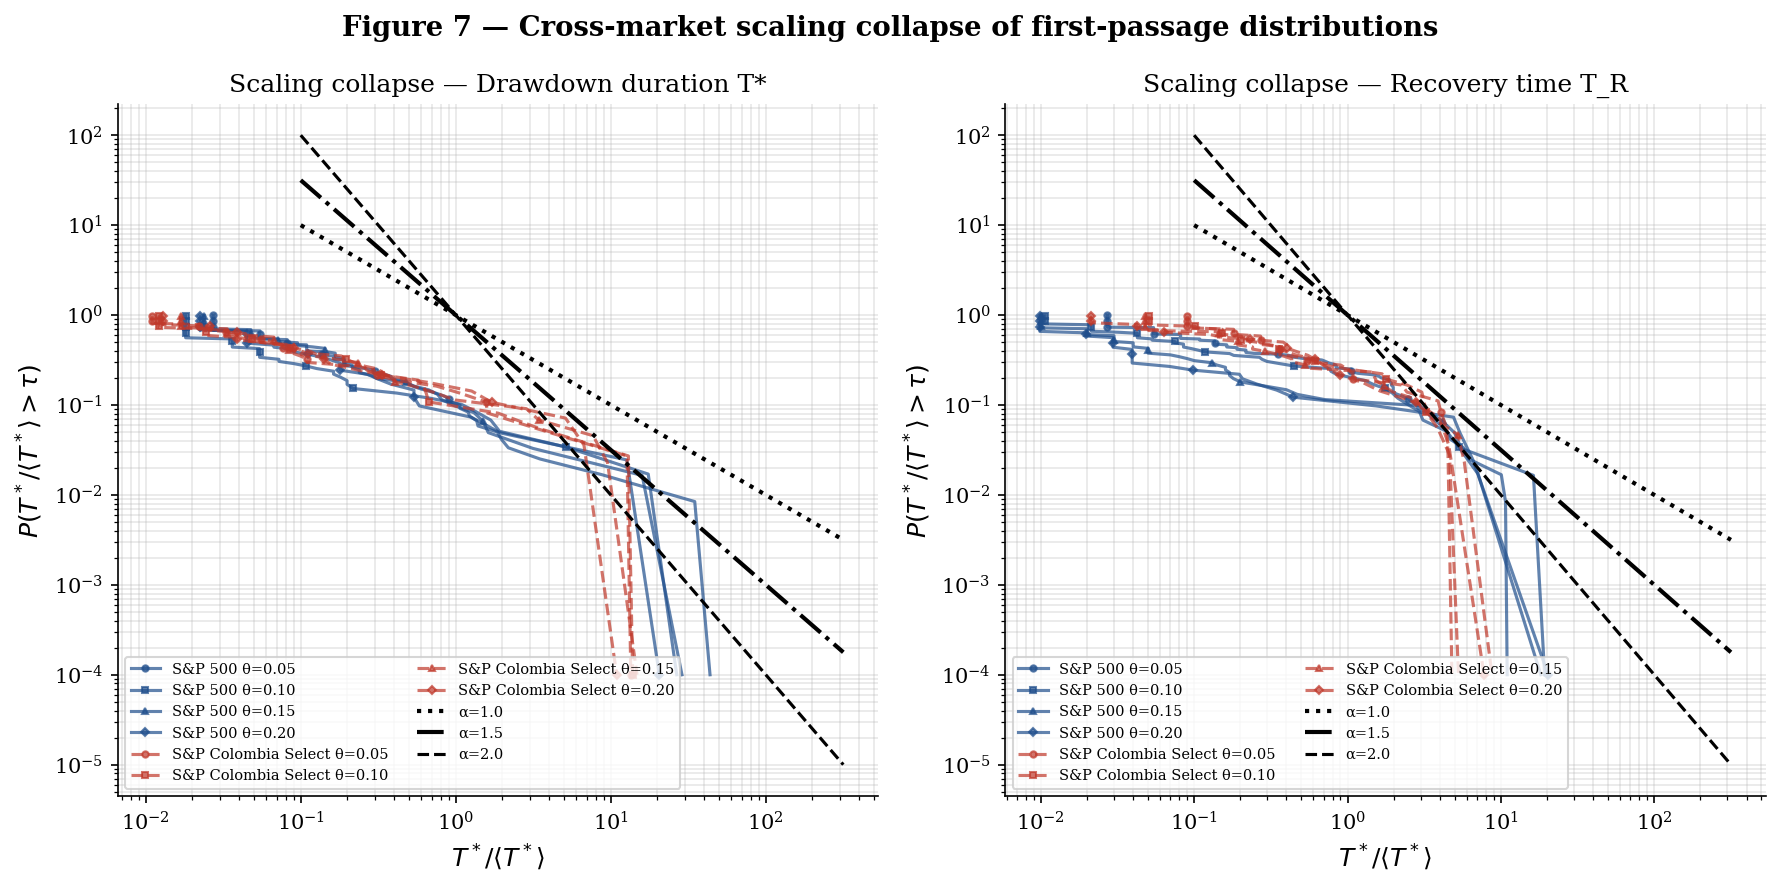

In [24]:
# --- Figura 5 actualizada: CCDF con exceedance data ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax_row, (name, color, label) in zip([axes[0], axes[1]], [
        ('sp500',  COLORS['sp500'],  'S&P 500'),
        ('colcap', COLORS['colcap'], 'S&P Colombia Select')]):

    for ax, key, title in zip(ax_row,
            ['fpt', 'rec'],
            ['Drawdown duration T*', 'Recovery time T_R']):

        for th, alpha_val in zip(THRESHOLDS, [0.4, 0.6, 0.8, 1.0]):
            times = fpt_exceed[name][key][th]
            if len(times) < 5:
                continue
            t_sorted = np.sort(times)
            ccdf     = 1 - np.arange(1, len(t_sorted)+1) / len(t_sorted)
            ax.loglog(t_sorted, ccdf + 1e-4, 'o-', color=color,
                      alpha=alpha_val, ms=3, lw=1,
                      label=f'θ={th:.2f} (N={len(times)})')

        ax.set_xlabel('Time (trading days)')
        ax.set_ylabel('P(T > t)')
        ax.set_title(f'{label} — {title}')
        ax.legend(fontsize=8)
        ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Figure 5 — CCDF of first-passage times (exceedance runs, log-log)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}fig05_fpt_ccdf.pdf', bbox_inches='tight')
plt.show()


# ============================================================
# Sección 6 — Tail exponent estimation
# ============================================================
from math import factorial

def hill_estimator(data, k_range=None):
    x = np.sort(data)[::-1]
    n = len(x)
    if k_range is None:
        k_max = min(80, n // 3)
        k_range = range(5, max(6, k_max))
    alphas = []
    for k in k_range:
        lx = np.log(x[:k]) - np.log(x[k])
        if np.any(lx <= 0):
            continue
        alphas.append(k / np.sum(lx))
    if not alphas:
        return np.nan, np.nan, [], list(k_range)
    alphas = np.array(alphas)
    return np.median(alphas), np.std(alphas), alphas, list(k_range)


def loglog_fit(times, pct_tail=70):
    t_sorted = np.sort(times)
    ccdf     = 1 - np.arange(1, len(t_sorted)+1) / len(t_sorted) + 1e-6
    t_min    = np.percentile(t_sorted, pct_tail)
    mask     = t_sorted >= t_min
    if mask.sum() < 5:
        return np.nan, np.nan
    slope, _, r, _, _ = stats.linregress(np.log(t_sorted[mask]),
                                          np.log(ccdf[mask]))
    return -slope, r**2


# --- Tabla de exponentes ---
print(f"{'Market':20s} | {'Type':10s} | {'θ':5s} | {'N':4s} | "
      f"{'α Hill':8s} | {'±σ':6s} | {'α OLS':7s} | {'R²':5s}")
print('-' * 78)

tail_results = {}
for name in MARKETS:
    tail_results[name] = {}
    for key in ['fpt', 'rec']:
        tail_results[name][key] = {}
        for th in THRESHOLDS:
            times = fpt_exceed[name][key][th]
            if len(times) < 10:
                continue
            a_h, a_std, _, _ = hill_estimator(times)
            a_ols, r2        = loglog_fit(times)
            tail_results[name][key][th] = {
                'alpha_hill': a_h, 'alpha_hill_std': a_std,
                'alpha_ols': a_ols, 'R2': r2, 'N': len(times)
            }
            print(f"{LABELS[name]:20s} | {key:10s} | {th:5.2f} | {len(times):4d} | "
                  f"{a_h:8.3f} | {a_std:6.3f} | {a_ols:7.3f} | {r2:5.3f}")


# --- Figura 6: Hill plot ---
fig, axes = plt.subplots(len(MARKETS), 2,
                          figsize=(11, 4 * len(MARKETS)))
if len(MARKETS) == 1:
    axes = axes[np.newaxis, :]

for i, (name, color, label) in enumerate(zip(
        MARKETS,
        [COLORS['sp500'], COLORS['colcap']],
        [LABELS[n] for n in MARKETS])):

    for ax, key, title in zip(axes[i],
            ['fpt', 'rec'],
            ['Drawdown duration T*', 'Recovery time T_R']):

        th_best = THRESHOLDS[1]   # θ=0.10
        times   = fpt_exceed[name][key][th_best]
        if len(times) < 10:
            ax.text(0.5, 0.5, 'Insufficient data',
                    transform=ax.transAxes, ha='center')
            continue

        a_h, a_std, alphas, ks = hill_estimator(times)
        if not len(alphas):
            continue

        ax.plot(list(ks)[:len(alphas)], alphas,
                'o-', color=color, ms=4, lw=1)
        ax.axhline(a_h, color='k', ls='--', lw=1.5,
                   label=f'α = {a_h:.2f} ± {a_std:.2f}')
        ax.fill_between(list(ks)[:len(alphas)],
                        a_h - a_std, a_h + a_std,
                        alpha=0.2, color='k')
        ax.set_xlabel('k (order statistics)')
        ax.set_ylabel('Hill α(k)')
        ax.set_title(f'{label} — {title} (θ={th_best})')
        ax.legend()

plt.suptitle('Figure 6 — Hill plot: stability of tail exponent α',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}fig06_hill_plot.pdf', bbox_inches='tight')
plt.show()


# ============================================================
# Sección 7 — Scaling collapse
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

ref_t = np.logspace(-1, 2.5, 300)

for ax, key, title in zip(axes,
        ['fpt', 'rec'],
        ['Drawdown duration T*', 'Recovery time T_R']):

    for name, color, label, ls in [
            ('sp500',  COLORS['sp500'],  'S&P 500', '-'),
            ('colcap', COLORS['colcap'], 'S&P Colombia Select', '--')]:

        if name not in MARKETS:
            continue

        for th, marker in zip(THRESHOLDS, ['o', 's', '^', 'D']):
            times = fpt_exceed[name][key][th]
            if len(times) < 10:
                continue
            mfpt     = np.mean(times)
            t_scaled = np.sort(times) / mfpt
            ccdf     = 1 - np.arange(1, len(t_scaled)+1) / len(t_scaled)
            ax.loglog(t_scaled, ccdf + 1e-4,
                      linestyle=ls, color=color, alpha=0.7,
                      marker=marker, ms=3,
                      markevery=max(1, len(t_scaled)//8),
                      label=f'{label} θ={th:.2f}')

    # Power-law references
    for alpha_ref, lw, ls2 in [(1.0, 2, ':'), (1.5, 2, '-.'), (2.0, 1.5, '--')]:
        ax.loglog(ref_t, ref_t**(-alpha_ref), 'k',
                  lw=lw, linestyle=ls2, label=f'α={alpha_ref}')

    ax.set_xlabel(r'$T^* / \langle T^* \rangle$')
    ax.set_ylabel(r'$P(T^* / \langle T^* \rangle > \tau)$')
    ax.set_title(f'Scaling collapse — {title}')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Figure 7 — Cross-market scaling collapse of first-passage distributions',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}fig07_scaling_collapse.pdf', bbox_inches='tight')
plt.show()

## 6. Tail Exponent Estimation

Fit the power-law tail:
$$P(T^* > t) \sim t^{-\alpha}$$

Use **Hill estimator** (MLE for Pareto tail) and compare with OLS regression on the log-log CCDF.  
**Central claim**: α is universal across markets → same universality class as marathon pacing collapse.

In [17]:
def hill_estimator(data, k_range=None):
    """
    Hill estimator for the tail index alpha.
    Returns alpha estimate and its asymptotic std.
    """
    x = np.sort(data)[::-1]   # descending
    n = len(x)
    if k_range is None:
        k_range = range(5, min(50, n // 3))

    alphas = []
    for k in k_range:
        lx = np.log(x[:k]) - np.log(x[k])   # log ratios
        alpha_k = k / np.sum(lx)
        alphas.append(alpha_k)

    alphas = np.array(alphas)
    # Plateau region: median of stable zone
    alpha_est = np.median(alphas)
    alpha_std = np.std(alphas)
    return alpha_est, alpha_std, alphas, list(k_range)


def loglog_fit(times, t_min_frac=0.3):
    """
    OLS power-law fit on log-log CCDF.
    Fits only to the upper tail (t > t_min_frac * max).
    Returns alpha, R².
    """
    t_sorted = np.sort(times)
    ccdf = 1 - np.arange(1, len(t_sorted)+1) / len(t_sorted) + 1e-6
    t_min = np.percentile(t_sorted, 70)   # upper 30% tail
    mask = t_sorted >= t_min
    if mask.sum() < 5:
        return np.nan, np.nan

    log_t = np.log(t_sorted[mask])
    log_c = np.log(ccdf[mask])
    slope, intercept, r, p, se = stats.linregress(log_t, log_c)
    return -slope, r**2


# --- Tail exponent table ---
print(f"{'Market':8s} | {'Type':8s} | {'θ':4s} | {'N':4s} | "
      f"{'α (Hill)':10s} | {'α (OLS)':10s} | {'R²':5s}")
print('-' * 68)

tail_results = {}

for name in ['sp500', 'colcap']:
    tail_results[name] = {}
    for key in ['fpt', 'rec']:
        tail_results[name][key] = {}
        for th in THRESHOLDS:
            times = fpt_results[name][key][th]
            if len(times) < 10:
                continue

            a_hill, a_std, _, _ = hill_estimator(times)
            a_ols, r2 = loglog_fit(times)

            tail_results[name][key][th] = {
                'alpha_hill': a_hill, 'alpha_hill_std': a_std,
                'alpha_ols': a_ols, 'R2': r2, 'N': len(times)
            }
            print(f"{name:8s} | {key:8s} | {th:4.1f} | {len(times):4d} | "
                  f"{a_hill:6.3f}±{a_std:.3f} | {a_ols:8.3f}  | {r2:5.3f}")

Market   | Type     | θ    | N    | α (Hill)   | α (OLS)    | R²   
--------------------------------------------------------------------
sp500    | fpt      |  0.5 |   17 |    nan±nan |    3.986  | 0.472
sp500    | rec      |  0.5 |   18 |  0.785±0.000 |    3.428  | 0.574


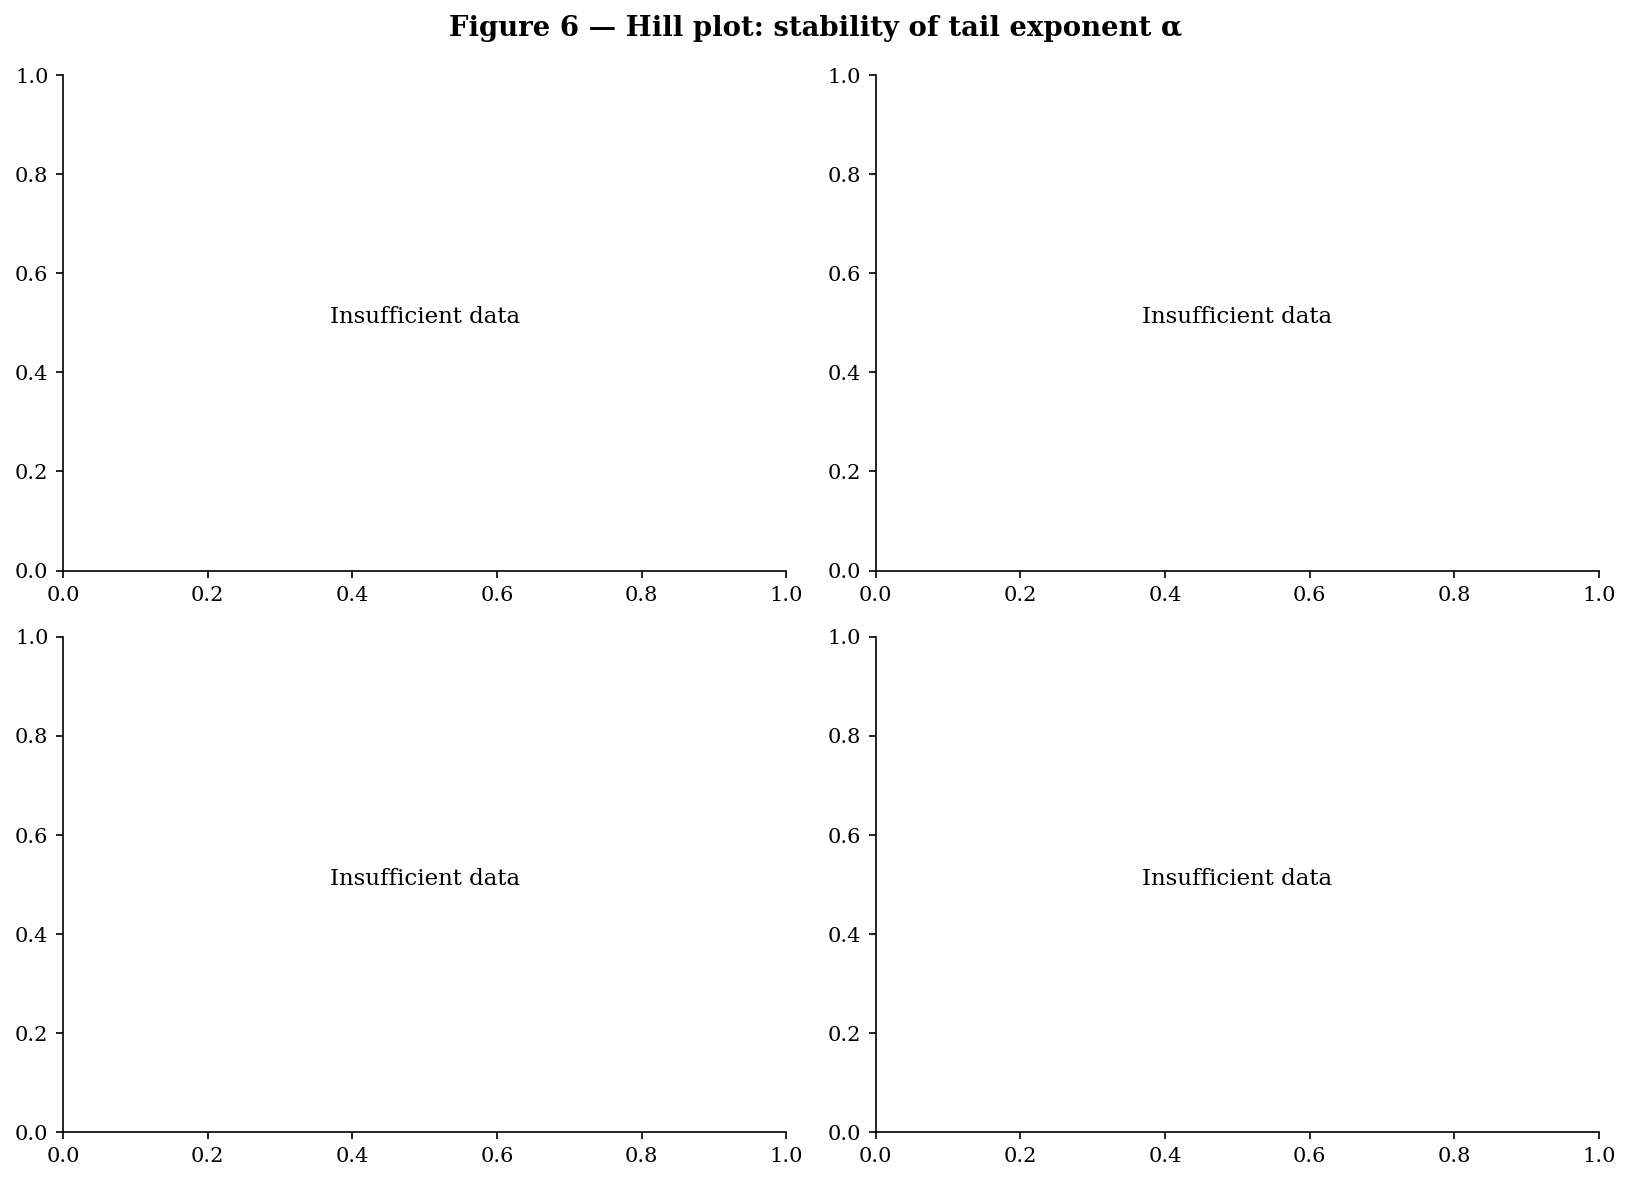

In [18]:
# --- Figure 6: Hill plot (stability of alpha estimate) ---
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax_row, (name, color, label) in zip([axes[0], axes[1]], [
        ('sp500',  COLORS['sp500'],  'S&P 500'),
        ('colcap', COLORS['colcap'], 'COLCAP')]):

    for ax, key, title in zip(ax_row, ['fpt', 'rec'],
                               ['Drawdown duration T*', 'Recovery time T_R']):

        th_best = THRESHOLDS[1]   # θ=1.0 typically has most data
        times = fpt_results[name][key][th_best]
        if len(times) < 10:
            ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes, ha='center')
            continue

        a_h, a_std, alphas, ks = hill_estimator(times)

        ax.plot(ks, alphas, 'o-', color=color, ms=4, lw=1)
        ax.axhline(a_h, color='k', ls='--', lw=1.2,
                   label=f'α = {a_h:.2f} ± {a_std:.2f}')
        ax.fill_between(ks,
                        [a_h - a_std]*len(ks),
                        [a_h + a_std]*len(ks),
                        alpha=0.2, color='k')
        ax.set_xlabel('k (number of order statistics)')
        ax.set_ylabel('Hill estimator α(k)')
        ax.set_title(f'{label} — {title} (θ={th_best})')
        ax.legend()

plt.suptitle('Figure 6 — Hill plot: stability of tail exponent α', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}fig06_hill_plot.pdf', bbox_inches='tight')
plt.show()

## 7. Cross-Market Universality — Scaling Collapse

Rescale the first-passage time distributions by the MFPT $\langle T^* \rangle$:
$$\hat{P}(T^*/\langle T^* \rangle > \tau) = f(\tau)$$

If collapse is achieved, all curves lie on a single master curve → universality claim.

In [ ]:
# --- Figure 7: Scaling collapse ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, key, title in zip(axes,
        ['fpt', 'rec'],
        ['Drawdown duration T*', 'Recovery time T_R']):

    all_alphas = []

    for name, color, label, ls in [
            ('sp500',  COLORS['sp500'],  'S&P 500', '-'),
            ('colcap', COLORS['colcap'], 'COLCAP',  '--')]:

        for th, marker in zip(THRESHOLDS, ['o', 's', '^', 'D']):
            times = fpt_results[name][key][th]
            if len(times) < 10:
                continue

            mfpt = np.mean(times)
            t_scaled = np.sort(times) / mfpt
            ccdf = 1 - np.arange(1, len(t_scaled)+1) / len(t_scaled)

            ax.loglog(t_scaled, ccdf + 1e-4,
                      linestyle=ls, color=color, alpha=0.7,
                      marker=marker, ms=3, markevery=max(1, len(t_scaled)//10),
                      label=f'{label} θ={th}')

    # Reference power-law
    t_ref = np.logspace(-0.5, 2, 200)
    for alpha_ref, lw in [(1.5, 2), (2.0, 1)]:
        ax.loglog(t_ref, t_ref**(-alpha_ref), 'k:', lw=lw,
                  label=f'α = {alpha_ref}')

    ax.set_xlabel(r'$T^* / \langle T^* \rangle$')
    ax.set_ylabel(r'$P(T^* / \langle T^* \rangle > \tau)$')
    ax.set_title(f'Scaling collapse — {title}')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Figure 7 — Cross-market scaling collapse of first-passage distributions',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}fig07_scaling_collapse.pdf', bbox_inches='tight')
plt.show()

## 8. GARCH(1,1) Benchmark

Fit a GARCH(1,1) to each return series and extract the implied first-passage times  
from simulated GARCH paths. Compare with the Langevin result.

In [25]:
try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except ImportError:
    print("arch library not found — install with: pip install arch")
    ARCH_AVAILABLE = False

garch_results = {}

if ARCH_AVAILABLE:
    for name in ['sp500', 'colcap']:
        r = returns[name] * 100   # arch expects percentage returns
        model = arch_model(r, vol='Garch', p=1, q=1, dist='Normal')
        res = model.fit(disp='off')
        garch_results[name] = res

        print(f"\n{name.upper()} — GARCH(1,1)")
        print(res.summary().tables[1])


SP500 — GARCH(1,1)
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0604  8.496e-03      7.115  1.118e-12 [4.380e-02,7.710e-02]

COLCAP — GARCH(1,1)
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0455  2.751e-02      1.655  9.791e-02 [-8.387e-03,9.944e-02]


In [26]:
# Simulate GARCH paths and extract drawdown FPTs
def simulate_garch_drawdowns(garch_fit, n_paths=500, n_steps=1000, threshold=0.05, seed=0):
    """
    Simulate GARCH(1,1) price paths and extract drawdown first-passage times.
    """
    rng = np.random.default_rng(seed)
    params = garch_fit.params

    omega = params.get('omega', params.get('Const', 0.01))
    alpha = params.get('alpha[1]', 0.05)
    beta  = params.get('beta[1]',  0.90)
    mu    = params.get('mu', 0.0)

    fpt_list = []
    rec_list = []

    for _ in range(n_paths):
        sigma2 = np.var(garch_fit.resid)
        log_price = [0.0]

        for t in range(n_steps):
            eps = rng.standard_normal()
            ret = (mu + np.sqrt(sigma2) * eps) / 100
            log_price.append(log_price[-1] + ret)
            e2 = (ret * 100 - mu)**2
            sigma2 = omega + alpha * e2 + beta * sigma2

        prices = np.exp(np.array(log_price))
        hwm = np.maximum.accumulate(prices)
        dd  = (hwm - prices) / hwm

        # Extract FPTs for this path
        in_dd = False
        start_i = None
        peak_i  = None

        for i, v in enumerate(dd):
            if not in_dd and v >= threshold:
                in_dd   = True
                start_i = i
                peak_i  = i
            elif in_dd:
                if v > dd[peak_i]:
                    peak_i = i
                if v < threshold * 0.05:
                    fpt_list.append(peak_i - start_i)
                    rec_list.append(i - peak_i)
                    in_dd = False

    return np.array(fpt_list), np.array(rec_list)


garch_fpt = {}
if ARCH_AVAILABLE:
    for name in ['sp500', 'colcap']:
        fpt_g, rec_g = simulate_garch_drawdowns(garch_results[name])
        garch_fpt[name] = {'fpt': fpt_g, 'rec': rec_g}
        print(f"{name.upper()} GARCH simulation: {len(fpt_g)} FPT events extracted")

SP500 GARCH simulation: 3221 FPT events extracted
COLCAP GARCH simulation: 4331 FPT events extracted


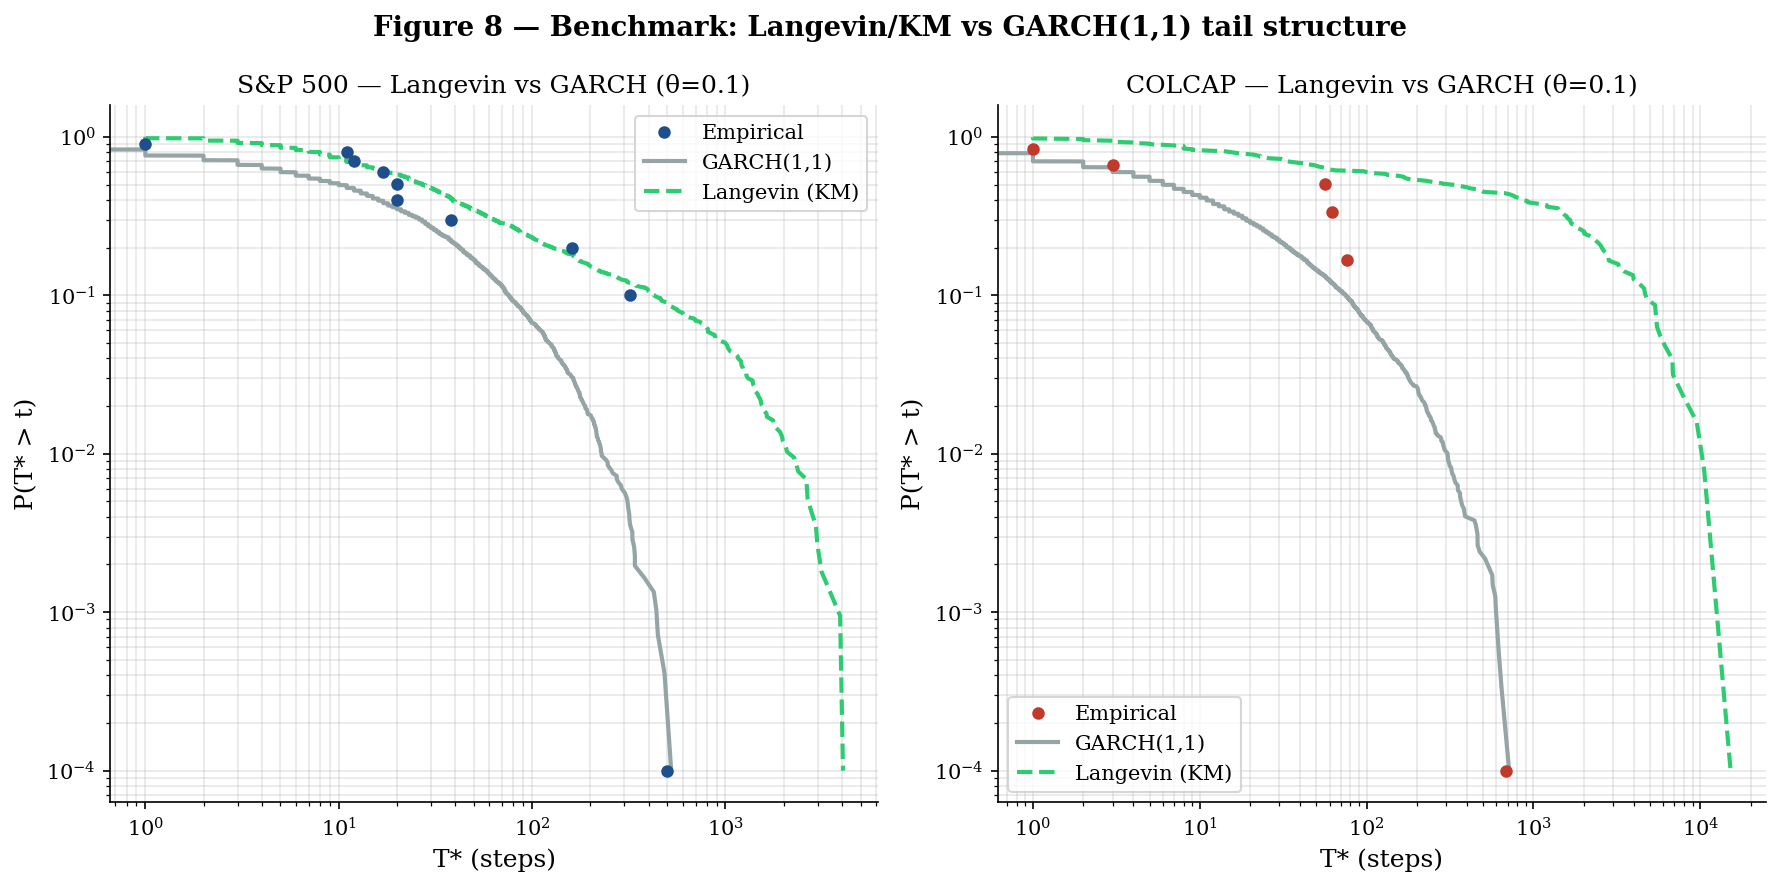

In [27]:
# --- Figure 8: Langevin vs GARCH comparison ---
if ARCH_AVAILABLE and garch_fpt:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for ax, (name, color, label) in zip(axes, [
            ('sp500',  COLORS['sp500'],  'S&P 500'),
            ('colcap', COLORS['colcap'], 'COLCAP')]):

        th = THRESHOLDS[1]   # θ=1.0

        # Empirical
        times_emp = fpt_results[name]['fpt'][th]
        if len(times_emp) >= 5:
            t_s = np.sort(times_emp)
            ccdf = 1 - np.arange(1, len(t_s)+1) / len(t_s)
            ax.loglog(t_s, ccdf + 1e-4, 'o', color=color, ms=5,
                      label='Empirical', zorder=5)

        # GARCH
        times_g = garch_fpt[name]['fpt']
        if len(times_g) >= 5:
            t_s = np.sort(times_g)
            ccdf = 1 - np.arange(1, len(t_s)+1) / len(t_s)
            ax.loglog(t_s, ccdf + 1e-4, '-', color=COLORS['garch'], lw=2,
                      label='GARCH(1,1)')

        # Langevin simulation
        fit = langevin_fits[name]
        x_sim = simulate_langevin(fit['D1'], fit['D2'], x0=0.5, n_steps=200000)
        # Extract FPTs from Langevin simulation
        fpt_lan = []
        in_ep = False
        st = None
        for i, v in enumerate(x_sim):
            if not in_ep and v >= th:
                in_ep = True; st = i
            elif in_ep and v < th * 0.1:
                fpt_lan.append(i - st); in_ep = False
        if len(fpt_lan) >= 5:
            fpt_lan = np.array(fpt_lan)
            t_s = np.sort(fpt_lan)
            ccdf = 1 - np.arange(1, len(t_s)+1) / len(t_s)
            ax.loglog(t_s, ccdf + 1e-4, '--', color=COLORS['theory'], lw=2,
                      label='Langevin (KM)')

        ax.set_xlabel('T* (steps)')
        ax.set_ylabel('P(T* > t)')
        ax.set_title(f'{label} — Langevin vs GARCH (θ={th})')
        ax.legend()
        ax.grid(True, which='both', alpha=0.3)

    plt.suptitle('Figure 8 — Benchmark: Langevin/KM vs GARCH(1,1) tail structure',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{FIGDIR}fig08_langevin_vs_garch.pdf', bbox_inches='tight')
    plt.show()
else:
    print('Skipping GARCH benchmark (arch not installed).')

## 9. Summary Table — Paper Results

In [28]:
# --- Build summary DataFrame ---
rows = []
for name in ['sp500', 'colcap']:
    for key in ['fpt', 'rec']:
        for th in THRESHOLDS:
            tr = tail_results[name][key].get(th, None)
            if tr is None:
                continue
            times = fpt_results[name][key][th]
            rows.append({
                'Market':       name.upper(),
                'Type':         'Duration' if key == 'fpt' else 'Recovery',
                'θ':            th,
                'N':            tr['N'],
                'MFPT (days)':  round(np.mean(times), 1),
                'α (Hill)':     round(tr['alpha_hill'], 3),
                '±σ':           round(tr['alpha_hill_std'], 3),
                'α (OLS)':      round(tr['alpha_ols'], 3) if not np.isnan(tr['alpha_ols']) else '-',
                'R²':           round(tr['R2'], 3) if not np.isnan(tr['R2']) else '-',
            })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

# Save as CSV for LaTeX table
df_summary.to_csv('results_summary.csv', index=False)
print('\nSaved → results_summary.csv')

Market     Type    θ   N  MFPT (days)  α (Hill)    ±σ  α (OLS)    R²
 SP500 Duration 0.05 120         50.2     0.768 0.085    1.303 0.672
 SP500 Duration 0.10  59        110.0     0.506 0.079    1.232 0.556
 SP500 Duration 0.15  61        148.0     0.704 0.064    1.550 0.653
 SP500 Duration 0.20  41        163.2     0.612 0.035    1.707 0.627
 SP500 Recovery 0.05 120         95.5     1.422 0.354    2.001 0.482
 SP500 Recovery 0.10  59        223.4     0.971 0.256    2.179 0.573
 SP500 Recovery 0.15  61        387.4     0.461 0.251    1.068 0.445
 SP500 Recovery 0.20  41        621.8     0.409 0.044    0.993 0.499
COLCAP Duration 0.05  37         40.3     0.543 0.093    1.763 0.493
COLCAP Duration 0.10  37        147.8     0.607 0.055    1.781 0.515
COLCAP Duration 0.15  44        118.0     0.562 0.031    1.572 0.467
COLCAP Duration 0.20  28        209.0     0.456 0.055    1.700 0.433
COLCAP Recovery 0.05  36         54.8     0.977 0.438    2.667 0.259
COLCAP Recovery 0.10  36        18

In [29]:
# --- Comparison with marathon PRE results (enter manually from your PRE paper) ---
# This is the key universality comparison for the paper

# TODO: replace these with actual values from your PRE paper
marathon_alpha_collapse = 1.8   # example — pace collapse tail exponent
marathon_alpha_recovery = 2.1   # example

print('=== UNIVERSALITY CLAIM SUMMARY ===')
print(f"Marathon pacing collapse  α ≈ {marathon_alpha_collapse:.2f}")
print()

for name in ['sp500', 'colcap']:
    tr = tail_results[name].get('fpt', {}).get(1.0, None)
    if tr:
        a = tr['alpha_hill']
        s = tr['alpha_hill_std']
        diff = abs(a - marathon_alpha_collapse) / marathon_alpha_collapse * 100
        print(f"{name.upper():8s} drawdown α = {a:.3f} ± {s:.3f}  "
              f"({diff:.1f}% from marathon value)")

=== UNIVERSALITY CLAIM SUMMARY ===
Marathon pacing collapse  α ≈ 1.80



---
## 10. Next Steps & TODO

- [ ] Verify COLCAP data quality — check for gaps, survivorship bias
- [ ] Add intraday data (1-min S&P 500) for higher statistics
- [ ] Pawula test: confirm $D^{(4)} \approx 0$ at all x
- [ ] Kolmogorov–Smirnov test: power-law vs log-normal vs exponential
- [ ] Bootstrap confidence intervals on α (1000 resamples)
- [ ] Mean first-passage time from Fokker–Planck: MFPT = ∫ dx / [D2(x) p_s(x)]
- [ ] Robustness: rolling 5-year windows, check stationarity of α
- [ ] Crisis periods: 2008, 2020 COVID — do tail exponents shift?
- [ ] LaTeX table from `results_summary.csv`
- [ ] Paper draft outline in Overleaf